# Lecture 11 — Convection & the Converged Atmosphere

*Stellar Spectroscopy from Scratch — rebuilding the physics of ATLAS and SYNTHE from first principles*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision. Schematics generated with **Gemini 3 Pro** (Nano Banana).*

*Every result in this book is checked against reference values computed with [**pykurucz**](https://arxiv.org/abs/2603.11693) — a pure-Python implementation of Kurucz's ATLAS12 and SYNTHE — shipped beside the lectures as small data files, so the notebooks need only NumPy to run.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- Explain why the **deep photosphere of a cool star convects**: where the radiative gradient exceeds the **adiabatic** gradient, the gas becomes unstable and carries part of the flux as rising and falling parcels rather than as radiation.
- Implement **mixing-length theory** (Kurucz's `CONVEC`): the adiabatic gradient $\nabla_{\rm ad}$, the superadiabaticity $\Delta = \nabla - \nabla_{\rm ad}$, the convective velocity and the **convective flux** $F_{\rm conv}$, with the thermodynamic derivatives computed by **re-running the equation of state** (Saha/Boltzmann + the electron-density charge balance of Lecture 2) at perturbed $T$ and $P$, and the optically-thick efficiency factor $\tau_b^2/(2+\tau_b^2)$.
- Add **convective overshoot** — the geometric smear that lets a parcel coast past the Schwarzschild boundary — and reproduce ATLAS's `OVERWT` blend.
- See that the mixing-length **convective flux is negligible in the line-forming layers** of this 1D model but reshapes the **deep-layer** structure, and that its flux feeds back into the temperature correction.
- State the **convergence criterion** — the physical requirement is flux constancy; the proxy ATLAS actually tests for is the deep-layer $\max|\Delta T/T|$ between iterations — and read the iteration history of a real model converging.
- Inspect the full **grey-start-to-convergence history** (28 iterations, shipped as the reference) and reproduce one from-scratch iteration from the converged model to the **precision floor of the reference** — the new convective flux, the corrected temperature, and the column mass — closing the loop the first lecture opened.

## Introduction: from one correction step to a converged atmosphere

Lecture 10 built **one** step of the radiative-equilibrium temperature correction: it measured how far the grey atmosphere's flux was from constant, and shifted the temperature to push it back. That was the engine. This lecture turns the engine into a machine that *converges* a model atmosphere, and it does so by adding the two pieces Lecture 10 deliberately left out. One honesty note up front, so the goal of this lecture is crisp: the model we converge here is **continuum-only** — the millions of spectral lines are switched off, deliberately, so the whole loop stays reproducible with NumPy alone. That is the converged *continuum* atmosphere, the convergence machinery proven to a fixed point on the simplest opacity. Switching the line blanket on — and reaching the *real* Sun — is the work of Part VI; this lecture builds the engine that Part VI then reruns unchanged.

The first is **iteration**. One correction does not converge a model: after we change the temperature, the equation of state (Lecture 2), the opacities (Lecture 3), the Rosseland mean and the fluxes (Lectures 8, 10) all change too, so we must recompute them and correct again — and again — until the flux stops drifting with depth and the temperature stops moving. A solar model takes a few dozen such iterations from a grey start.

The second is **convection**. In the deep photosphere of a cool star like the Sun, radiation alone cannot carry all the flux: the temperature gradient steepens until the gas becomes **convectively unstable**, and rising hot parcels and sinking cool ones take over a large fraction of the energy transport. The temperature correction has to know about that convective flux, or it will get the deep structure wrong. In a 1D mixing-length model the **convective flux is negligible where the spectral lines form** (the upper photosphere, which stays radiative), so none of our continuum-and-line spectrum work in Lectures 1–8 needed it — but it matters for the *structure* of the deep layers, and therefore for a self-consistent model. (In 3D, granulation, convective velocities, and overshoot do leave a mark on real line profiles even where the 1D convective flux is small; that physics lives beyond this book's 1D scope.)

We reuse, unchanged, every engine the book has built: the continuum opacity **KAPP** (Lecture 3, supplied as a given input), the **JOSH** moment solver (Lecture 8) for the per-frequency flux, the **Rosseland mean** and the **temperature correction TCORR** (Lecture 10). The genuinely new physics is the mixing-length **convection** kernel and the **convergence** loop that ties everything together.

## Setup and the reference

We import only NumPy and Matplotlib. The benchmark target is `reference/converged_ref.npz`, produced once by the production code on the solar parameters ($T_{\rm eff}=5770$ K, $\log g=4.44$) in the clean configuration this book uses: **continuum opacity only** (no line blanketing, so no multi-gigabyte line lists), **convection on** (mixing length $1.25$), and **serial** execution so the result is bit-reproducible. The production code was run from the **grey start** of Lecture 9 all the way to convergence — stopped when the deep-layer temperature correction fell below $10^{-4}$, the proxy ATLAS uses for flux constancy — which took **28 iterations**.

The file ships three things. First, the **converged model** itself ($T$, column mass `rhox`, pressure, electron density, Rosseland opacity, and the convective flux `flxcnv`). Second, the **convergence history** — $\max|\Delta T/T|$ per iteration — so we can plot a real model settling. Third, everything one from-scratch iteration *from the converged model* needs: the per-frequency **continuum opacity** (the Lecture-3 KAPP output, a given input) and the convective inputs (`ptotal`, `rho`, `abross`). The **radiation pressure** $P_{\rm rad}$ — which Lecture 10 read from the reference — is *not* in that input list, and neither is its surface companion $P_{\rm radk}$: we compute **both** from scratch in the frequency sweep below — the depth-varying `RADIAP` moment *and* its surface K-integral — and the stored `prad_conv`/`pradk_conv` are used only to *check* our result. The one new ingredient that buys us the surface piece is a tiny fixed quadrature table, `reference/josh_ck.npz`, the JOSH K-moment weights — shipped read-only exactly like the $\Lambda$- and H-operator tables, and described where we use it.

The equation of state enters convection through four thermodynamic derivatives (next-to-next section), and ATLAS forms those by **finite-differencing** the EOS at $T,P\pm0.1\%$. Rather than ship the perturbed samples as a given, we **re-run the equation of state ourselves** at those four perturbed points — the Saha/Boltzmann ionization, the partition functions, and the electron-density charge balance of Lecture 2 — from a small companion file `reference/convec_gaps_inputs.npz`. That file carries **no answers**: only the $(T,P)$ state, the abundances, the previous-iteration $(n_e, n_{\rm atom}, q^2)$ seeds, and the tabulated atomic **data** the partition functions consume (energy levels, statistical weights, ionization tables) — exactly the atomic data Lecture 2 reuses. We compute the perturbed densities from scratch and verify them, bit-for-bit, against the converged model's own samples.

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5})

# the converged solar model and the Lecture 8 JOSH tables are the only inputs
REF = np.load(pathlib.Path("..") / "reference" / "converged_ref.npz")
JT  = np.load(pathlib.Path("..") / "reference" / "josh_tables.npz")   # Lecture 8 tables
# the EOS state + atomic data we re-run the equation of state on (carries NO answers)
EOS = np.load(pathlib.Path("..") / "reference" / "convec_gaps_inputs.npz")

TEFF = float(REF["teff"]); GRAV = float(REF["gravity_cgs"]); LOGG = float(np.log10(GRAV))
N_ITER = int(REF["n_iterations"])

print(f"target: converged continuum-only model for Teff = {TEFF:.0f} K, log g = {LOGG:.2f}")
print(f"  production run: grey start -> convergence in {N_ITER} iterations (convection ON)")
print(f"  continuum grid: {REF['freq_hz'].size} frequencies x {REF['T_conv'].size} layers")

target: converged continuum-only model for Teff = 5770 K, log g = 4.44
  production run: grey start -> convergence in 28 iterations (convection ON)
  continuum grid: 30000 frequencies x 80 layers


## What "converged" means: flux constancy

Radiative (plus convective) equilibrium demands that the **total** flux — radiative plus convective — be the same at every depth, equal to $\sigma T_{\rm eff}^4$. ATLAS does not test the flux directly; it tests the thing the flux drives, the **temperature change between successive iterations**. When the model is converged, one more correction barely moves the temperature, so the convergence metric is

$$\max_{j}\ \left|\frac{T^{(N)}_j - T^{(N-1)}_j}{T^{(N)}_j}\right| < 10^{-4},$$

the maximum fractional temperature change taken over the **deep layers** (ATLAS's `checkconv` uses Fortran layer numbers 40–75 of the 80-layer grid, i.e. the 1-based indices — the upper layers are noisier and settle last in absolute terms but are less diagnostic of the global energy balance, so ATLAS does not use them as the stopping criterion). The loop stops when this drops below $10^{-4}$, after a minimum number of iterations. The reference shipped that history; here it is.

In [2]:
# max|dT/T| over the deep layers 40..75 (the checkconv metric), per iteration
dlnt  = REF["dlnt_history"]
# max|dT/T| over ALL layers, per iteration -- the top layers settle last
dtmax = REF["dtmax_history"]

print(" iter   dTmax(all)    checkconv_dlnt(deep)")
for i in range(dlnt.size):
    flag = "  <- converged" if dlnt[i] < 1e-4 else ""
    print(f"  {i+1:3d}    {dtmax[i]:.3e}     {dlnt[i]:.3e}{flag}")
print(f"\\nconverged when deep-layer max|dT/T| < 1e-4 (Fortran checkconv.f90)")
print(f"determinism: two full runs identical  "
      f"T={bool(int(REF['determinism_T']))}  RHOX={bool(int(REF['determinism_R']))}")

 iter   dTmax(all)    checkconv_dlnt(deep)
    1    6.262e-01     1.084e+00
    2    7.720e-02     8.365e-02
    3    6.739e-02     7.227e-02
    4    4.517e-02     4.731e-02
    5    3.000e-02     2.647e-02
    6    3.264e-02     2.367e-02
    7    3.498e-02     2.603e-02
    8    3.754e-02     2.611e-02
    9    4.377e-02     2.747e-02
   10    5.701e-02     3.416e-02
   11    8.548e-02     4.169e-02
   12    1.614e-01     1.301e-02
   13    1.811e-01     5.094e-03
   14    4.444e-02     1.503e-03
   15    4.997e-02     8.095e-04
   16    2.368e-02     5.384e-04
   17    6.056e-03     4.076e-04
   18    1.613e-03     3.748e-04
   19    6.189e-04     2.891e-04
   20    5.201e-04     2.458e-04
   21    4.907e-04     2.063e-04
   22    4.705e-04     1.732e-04
   23    4.523e-04     1.546e-04
   24    4.038e-04     1.366e-04
   25    3.534e-04     1.198e-04
   26    3.357e-04     1.184e-04
   27    3.071e-04     1.006e-04
   28    3.034e-04     8.742e-05  <- converged
\nconverged when de

The deep-layer metric falls monotonically from order unity (the grey start is far from equilibrium) toward $10^{-4}$; the all-layer metric stalls higher because the thin **top** layers keep jittering at the $10^{-4}$ level even when the energy-carrying deep layers are settled — which is exactly why `checkconv` looks only at the deep layers. We will plot this curve at the end, next to the final flux-constancy check.

## The numerical toolbox (Lecture 8)

As in Lecture 10, every integral, derivative, and grid remap below is built from the four Fortran kernels of Lecture 8, reproduced compactly. `parcoe` fits a smoothly-blended parabola through each triple of points; `integ` integrates with each interval's parabola (every optical depth and flux integral); `deriv` is the cubic-tangent derivative ATLAS uses for gradients like $dT/d\rho x$; `map1` is the piecewise-quadratic remap between depth grids. The convection kernel needs `deriv` for the temperature and opacity gradients and `integ` for the geometric height.

In [3]:
def parcoe(f, x):
    """Smoothly-blended parabolic coefficients a,b,c so f ~ a + b x + c x^2 (Fortran PARCOE)."""
    nn = f.size; a = np.zeros(nn); b = np.zeros(nn); c = np.zeros(nn)
    if nn == 1: a[0] = f[0]; return a, b, c
    b[0] = (f[1]-f[0])/(x[1]-x[0]); a[0] = f[0]-x[0]*b[0]                # endpoints: straight line
    n1 = nn-1
    b[-1] = (f[-1]-f[n1-1])/(x[-1]-x[n1-1]); a[-1] = f[-1]-x[-1]*b[-1]
    if nn == 2: return a, b, c
    for j in range(1, n1):                                              # interior: parabola through 3 points
        j1 = j-1; d = (f[j]-f[j1])/(x[j]-x[j1])
        c[j] = f[j+1]/((x[j+1]-x[j])*(x[j+1]-x[j1])) + (f[j1]/(x[j+1]-x[j1]) - f[j]/(x[j+1]-x[j]))/(x[j]-x[j1])
        b[j] = d - (x[j]+x[j1])*c[j]; a[j] = f[j1] - x[j1]*d + x[j]*x[j1]*c[j]
    c[1] = 0.0; b[1] = (f[2]-f[1])/(x[2]-x[1]); a[1] = f[1]-x[1]*b[1]   # 2nd, 3rd points forced linear
    if nn > 3: c[2] = 0.0; b[2] = (f[3]-f[2])/(x[3]-x[2]); a[2] = f[2]-x[2]*b[2]
    for j in range(1, n1):                                             # blend each parabola with its neighbour
        if c[j] == 0.0: continue
        j1 = min(j+1, nn-1); den = abs(c[j1])+abs(c[j]); wt = abs(c[j1])/den if den > 0 else 0.0   # curvature weight
        a[j] = a[j1]+wt*(a[j]-a[j1]); b[j] = b[j1]+wt*(b[j]-b[j1]); c[j] = c[j1]+wt*(c[j]-c[j1])
    a[n1-1] = a[-1]; b[n1-1] = b[-1]; c[n1-1] = c[-1]
    return a, b, c

`integ` and `deriv` ride on those parabolic coefficients. `integ` analytically integrates each interval's parabola and accumulates the running sum, seeded at `start` — the quadrature behind every optical depth and flux integral here; `deriv` returns ATLAS's curvature-limited cubic-tangent derivative $df/dx$, used for the temperature and opacity gradients the convection kernel needs.

In [4]:
def integ(x, f, start):
    """Cumulative integral of f dx, each interval using its left-point parabola (Fortran INTEG)."""
    nn = f.size; out = np.zeros(nn)
    if nn == 0: return out
    a, b, c = parcoe(f, x); out[0] = start
    for i in range(nn-1):
        dx = x[i+1]-x[i]
        term = a[i] + 0.5*b[i]*(x[i+1]+x[i]) + (c[i]/3.0)*((x[i+1]+x[i])*x[i+1] + x[i]*x[i])
        out[i+1] = out[i] + term*dx
    return out

def deriv(x, f):
    """Cubic-tangent derivative df/dx (Fortran DERIV)."""
    nn = f.size; d = np.zeros(nn)
    if nn < 2: return d
    d[0] = (f[1]-f[0])/(x[1]-x[0]); d[-1] = (f[-1]-f[-2])/(x[-1]-x[-2])
    if nn == 2: return d
    s = abs(x[1]-x[0])/(x[1]-x[0]) if x[1] != x[0] else 1.0
    for j in range(1, nn-1):
        scale = max(abs(f[j-1]), abs(f[j]), abs(f[j+1]))
        scale = scale/abs(x[j]) if x[j] != 0.0 else scale
        if scale == 0.0: scale = 1.0
        d1 = (f[j+1]-f[j])/(x[j+1]-x[j])/scale; d0 = (f[j]-f[j-1])/(x[j]-x[j-1])/scale
        tan1 = d1/(s*np.sqrt(1.0+d1*d1)+1.0); tan0 = d0/(s*np.sqrt(1.0+d0*d0)+1.0)
        d[j] = (tan1+tan0)/(1.0-tan1*tan0)*scale
    return d

The last kernel, `map1`, is the piecewise-quadratic remap between depth grids. It is a single Fortran state machine: for each target point it advances a cursor through the source grid, fits a backward and a forward parabola around the bracket (reusing the previous step's forward fit when it can), blends them by curvature weight, and evaluates — falling back to straight lines at the ends. `map1_scalar` wraps it for a single point, and `_nz_signed` is the small signed-floor guard the convection code uses to avoid dividing by a near-zero value.

In [5]:
def map1(xold, fold, xnew):
    """Piecewise-quadratic remap matching Fortran MAP1.  Returns (fnew, ll-1)."""
    nold, nnew = xold.size, xnew.size; fnew = np.zeros(nnew)
    if nold == 0 or nnew == 0: return fnew, 0
    xo = np.empty(nold+1); fo = np.empty(nold+1); xo[1:] = xold; fo[1:] = fold
    l = 2; ll = 0; cfor = bfor = afor = cbac = bbac = abac = a = b = c = 0.0
    for k in range(1, nnew+1):
        xk = xnew[k-1]
        while True:
            if xk < xo[l]:
                if l == ll: break
                if l == 2 or l == 3:
                    l = min(nold, l); c = 0.0
                    b = (fo[l]-fo[l-1])/(xo[l]-xo[l-1]); a = fo[l]-xo[l]*b; ll = l; break
                l1 = l-1
                if l > ll+1 or l == 3 or l == 4:
                    l2 = l-2; d = (fo[l1]-fo[l2])/(xo[l1]-xo[l2])
                    cbac = fo[l]/((xo[l]-xo[l1])*(xo[l]-xo[l2])) + (fo[l2]/(xo[l]-xo[l2]) - fo[l1]/(xo[l]-xo[l1]))/(xo[l1]-xo[l2])
                    bbac = d-(xo[l1]+xo[l2])*cbac; abac = fo[l2]-xo[l2]*d+xo[l1]*xo[l2]*cbac
                else:
                    cbac, bbac, abac = cfor, bfor, afor
                if l >= nold:
                    c, b, a, ll = cbac, bbac, abac, l; break
                d = (fo[l]-fo[l1])/(xo[l]-xo[l1])
                cfor = fo[l+1]/((xo[l+1]-xo[l])*(xo[l+1]-xo[l1])) + (fo[l1]/(xo[l+1]-xo[l1]) - fo[l]/(xo[l+1]-xo[l]))/(xo[l]-xo[l1])
                bfor = d-(xo[l]+xo[l1])*cfor; afor = fo[l1]-xo[l1]*d+xo[l]*xo[l1]*cfor
                wt = abs(cfor)/(abs(cfor)+abs(cbac)) if abs(cfor) != 0.0 else 0.0
                a = afor+wt*(abac-afor); b = bfor+wt*(bbac-bfor); c = cfor+wt*(cbac-cfor); ll = l; break
            l += 1
            if l > nold:
                l = min(nold, l); c = 0.0
                b = (fo[l]-fo[l-1])/(xo[l]-xo[l-1]); a = fo[l]-xo[l]*b; ll = l; break
        fnew[k-1] = a + (b + c*xk)*xk
    return fnew, max(ll-1, 0)

def map1_scalar(xold, fold, xnew_val):
    out, _ = map1(np.asarray(xold), np.asarray(fold), np.asarray([xnew_val])); return float(out[0])

def _nz_signed(x, eps=1e-300):
    """Replace a value too close to zero with a small SIGNED floor (Fortran guard)."""
    return x if abs(x) >= eps else (eps if x >= 0.0 else -eps)

## Constants and the converged model

We use exactly the constants ATLAS uses. We then load the **converged model** as the starting point of our from-scratch iteration: temperature `T`, column mass `rhox`, gas pressure `p_in`, mass density `rho_in`, and the total pressure. The single number that sets the energy balance is the target Eddington flux $H = \sigma T_{\rm eff}^4/(4\pi)$; the **total** flux (radiative + convective) must equal this at every layer.

The radiative quantity we deliberately do **not** read here is the **radiation pressure** $P_{\rm rad}$ — and this lecture closes it completely. In Lecture 10 we read it from the reference; here we *compute* it from scratch during the frequency sweep below (the `RADIAP` moment $\frac{4\pi}{c}\int\kappa_\nu H_\nu\,d\nu$, integrated down the column), exactly as ATLAS does, so the convective $dP/dT$ term and the hydrostatic density correction both run on a $P_{\rm rad}$ we built ourselves. ATLAS adds to it a scalar **surface K-integral** `pradk0` — the second moment $\frac{4\pi}{c}\int K_\nu(0)\,d\nu$ of the *emergent* radiation field at the very top boundary — to form `PRADK = PRAD + pradk0`, the quantity the convective $dP/dT$ term reads. Lecture 10 read that scalar from the reference; here we compute it too, from this same sweep's JOSH surface radiation field (the K-moment section below). Nothing about the radiation pressure is read anymore — only one small fixed quadrature table, the JOSH K-moment weights, is needed, shipped read-only like the $\Lambda$- and H-operators.

A note on notation, to keep a factor of $4\pi$ straight. Throughout the code `flux` and `flxrad` are **Eddington fluxes** — the first angular moment $H$ of the intensity, with the physical flux $F = 4\pi H$. The convective flux arrays `flxcnv`/`cnvflx` are carried in the **same units** as `flxrad`, i.e. as $F_{\rm conv}/4\pi$: the $4\pi$ is folded once into the flux scale `fluxco` (which divides by `FOURPI`), so `cnvflx` adds **directly** to `flxrad` in every total-flux expression — the defect is $H + F_{\rm conv}/4\pi - H_{\rm target}$, with no stray $4\pi$. Only the flux-constancy plots multiply by $4\pi$, to display the physical flux $F$ against $\sigma T_{\rm eff}^4$.

In [6]:
SIGMA  = 5.6697e-5     # Stefan-Boltzmann constant [erg cm^-2 s^-1 K^-4]
PLANCK = 6.6256e-27    # Planck constant h [erg s]
KBOLTZ = 1.38054e-16   # Boltzmann constant k [erg/K]
FOURPI = 12.5664       # 4 pi, written explicitly by ATLAS

T      = REF["T_conv"].astype(np.float64)       # converged temperature [K], 80 layers
rhox   = REF["rhox_conv"].astype(np.float64)    # column mass RHOX [g/cm^2]
p_in   = REF["p_conv"].astype(np.float64)       # gas pressure [dyn/cm^2]
rho_in = REF["rho_conv"].astype(np.float64)     # mass density [g/cm^3]
ptotal = REF["ptotal_conv"].astype(np.float64)  # total pressure GRAV*RHOX + PZERO
n = T.size

# nothing radiation-pressure is read: PRAD (depth-varying) AND pradk0 (the surface K-integral)
# are both COMPUTED from the JOSH moments of the sweep below; prad_conv/pradk_conv only cross-check.

hkt  = PLANCK / np.maximum(T * KBOLTZ, 1e-300)  # h/(kT) per layer (nu factored in later)
flux = SIGMA / FOURPI * TEFF**4                 # target Eddington flux H = sigma Teff^4 / (4 pi)
print(f"target Eddington flux  H = {flux:.4e} erg cm^-2 s^-1  (physical flux F = 4 pi H = sigma Teff^4)")

target Eddington flux  H = 5.0009e+09 erg cm^-2 s^-1  (physical flux F = 4 pi H = sigma Teff^4)


## The per-frequency flux: JOSH and the Rosseland mean (Lecture 10)

The temperature correction needs four depth integrals over the continuum spectrum, exactly as in Lecture 10: the depth-resolved Eddington flux $H_\nu(\tau)$ and the moment $(J_\nu-S_\nu)(\tau)$ at each frequency, summed with the quadrature weights into `flxrad` (radiative flux), `rjmins`, `rdabh`, and the $\Lambda$-diagonal `rdiagj`; plus the Rosseland accumulator that becomes $\kappa_{\rm Ross}$. We carry over the JOSH full-depth kernel and the $E_3$ exponential integral from Lecture 10 verbatim; the only float32 step in the whole pipeline is JOSH's inner $\Lambda$-iteration, and it is what sets the precision floor. We fold the JOSH kernel and the helpers into one cell here to keep the focus on the new physics — the convection that follows.

In [7]:
XTAU  = JT["xtau"].astype(np.float64)             # JOSH fixed optical-depth grid
CH    = JT["ch"].astype(np.float64)
COEFJ = JT["coefj"].astype(np.float64)            # Lambda operator on the fixed grid
CH_MAT = REF["josh_coefh"].astype(np.float64)     # H-moment operator (shipped with the reference)
# CK: the fixed surface K-moment weights (the K analog of the CH surface-flux weights), shipped
# read-only as reference/josh_ck.npz.  Cast to float32 so CK . xs matches ATLAS's REAL*4 KNU dot.
CKF = np.load(pathlib.Path("..") / "reference" / "josh_ck.npz")
CK_W = CKF["ck"].astype(np.float32)               # K-moment quadrature weights on the same XTAU grid
ITER_TOL = 1.0e-5

def expi3(x):
    """E3 exponential integral (Fortran EXPI N=3), used by the Lambda-diagonal integral."""
    a = (-44178.5471728217, 57721.7247139444, 9938.31388962037, 1842.11088668, 101.093806161906, 5.03416184097568)
    b = (76537.3323337614, 32597.1881290275, 6106.10794245759, 635.419418378382, 37.2298352833327)
    c = (4.65627107975096e-7, 0.999979577051595, 9.04161556946329, 24.3784088791317, 23.0192559391333, 6.90522522784444, 0.430967839469389)
    dco = (10.0411643829054, 32.4264210695138, 41.2807841891424, 20.4494785013794, 3.31909213593302, 0.103400130404874)
    e = (-0.999999999998447, -26.6271060431811, -241.055827097015, -895.927957772937, -1298.85688746484, -545.374158883133, -5.66575206533869)
    fco = (28.6271060422192, 292.310039388533, 1332.78537748257, 2777.61949509163, 2404.01713225909, 631.6574832808)
    if x <= 0.0: ex1 = 0.0
    else:
        ex = np.exp(-x)
        if x > 4.0:
            ex1 = (ex + ex*(e[0]+(e[1]+(e[2]+(e[3]+(e[4]+(e[5]+e[6]/x)/x)/x)/x)/x)/x)/(x+fco[0]+(fco[1]+(fco[2]+(fco[3]+(fco[4]+fco[5]/x)/x)/x)/x)/x))/x
        elif x > 1.0:
            ex1 = ex*(c[6]+(c[5]+(c[4]+(c[3]+(c[2]+(c[1]+c[0]*x)*x)*x)*x)*x)*x)/(dco[5]+(dco[4]+(dco[3]+(dco[2]+(dco[1]+(dco[0]+x)*x)*x)*x)*x)*x)
        else:
            ex1 = (a[0]+(a[1]+(a[2]+(a[3]+(a[4]+a[5]*x)*x)*x)*x)*x)/(b[0]+(b[1]+(b[2]+(b[3]+(b[4]+x)*x)*x)*x)*x) - np.log(x)
    out = ex1
    for i in range(1, 3): out = (np.exp(-x) - x*out)/float(i)
    return out

`josh_profiles` is the Lecture 8/10 JOSH kernel, carried over verbatim, run for the full depth profile at one continuum frequency. It forms the per-frequency optics (total extinction, scattering fraction, thermal source, monochromatic $\tau_\nu$), maps them onto JOSH's fixed 51-point grid and runs the **float32** $\Lambda$-iteration that solves the scattering problem there, solves the optically thin outer layers directly on the physical grid, and reads the deep-layer moments off the grid solution — returning $\tau_\nu$, $H_\nu$, $(J_\nu - S_\nu)$, $\kappa_\nu$, and $\alpha_\nu$ at every layer. Two pieces are cleanly separable from the float32 inner sweep — the optics setup and the deep-layer physical-grid solve — so we lift them into named helpers first.

**The per-frequency optics.** `josh_optics` forms the four quantities every JOSH frequency starts from: the total extinction $\kappa_\nu = \kappa^{\rm abs}_\nu + \sigma_\nu$, the scattering fraction $\alpha_\nu = \sigma_\nu/\kappa_\nu$, the continuum thermal source $\bar S_\nu$, and the monochromatic optical depth $\tau_\nu = \int\kappa_\nu\,d(\rho x)$. Moved out verbatim.

In [8]:
def josh_optics(acont, scont, sigmac, rhox, bnu):
    """Per-frequency JOSH optics: total extinction, scattering fraction, thermal source, tau_nu (Lecture 8/10)."""
    abtot = np.maximum(acont + sigmac, 1e-300)          # total extinction
    alpha = sigmac / abtot                                # scattering fraction
    snubar = bnu.copy()
    np.divide(acont*scont, acont, out=snubar, where=acont > 0.0)   # thermal source (continuum)
    taunu = integ(rhox, abtot, abtot[0]*rhox[0])         # monochromatic optical depth
    return abtot, alpha, snubar, taunu

**The deep-layer solve.** Below the optically-thin surface that JOSH's fixed grid resolves, the moments are solved directly on the physical $\tau_\nu$ grid: $H_\nu = \tfrac13 dS_\nu/d\tau_\nu$ (diffusion), $(J_\nu - S_\nu) = dH_\nu/d\tau_\nu$, then the source is updated for scattering, with two negativity guards that fall back to the Planck function. `josh_deep_solve` runs that iteration in place on `snu`, `snubar`, `hnu`, `jnu`, `jmins`; it is the same iteration moved out, called at the same point.

In [9]:
def josh_deep_solve(snu, snubar, hnu, jnu, jmins, taunu, alpha, bnu, nl, nxtau, m0, nmj0, maxj1):
    """Deep-layer moment solve on the physical TAUNU grid, in place (Lecture 8/10 JOSH)."""
    for _ in range(nxtau):                                # deep layers solved on the physical TAUNU grid
        error = 0.0; ifneg = 0
        if np.any(snu[m0:] <= 0.0): ifneg = 1; snubar[m0:] = bnu[m0:]; snu[m0:] = bnu[m0:]   # negativity guard
        hnu[m0:] = deriv(taunu[m0:], snu[m0:])/3.0        # H = (1/3) dS/dtau (diffusion)
        if np.any(hnu[m0:] <= 0.0):                       # second guard: reset to Planck if H went negative
            ifneg = 1; snubar[m0:] = bnu[m0:]; snu[m0:] = bnu[m0:]; hnu[m0:] = deriv(taunu[m0:], snu[m0:])/3.0
        jmins[nmj0:] = deriv(taunu[nmj0:], hnu[nmj0:])    # (J - S) = dH/dtau
        for j in range(maxj1-1, nl):
            if ifneg == 1: jmins[j] = 0.0
            jnu[j] = jmins[j] + snu[j]                     # mean intensity J
            snew = (1.0-alpha[j])*snubar[j] + alpha[j]*jnu[j]                  # updated source (scattering)
            error += abs(snew-snu[j])/max(abs(snew), 1e-300); snu[j] = snew
        if error < ITER_TOL: break

**The surface-grid setup.** Before the float32 sweep can run, the thermal source and scattering fraction are remapped from the physical $\tau_\nu$ grid onto JOSH's fixed `XTAU` grid, cast to float32, clamped (a positive floor on $\bar S$, a $[0,\cdot]$ clamp on $\alpha$), and the grid points above the physical surface are filled with the surface values. From those, the diagonal of $(1-\alpha\Lambda)$ and the fixed thermal part $(1-\alpha)\bar S$ are precomputed. `josh_surface_setup` does exactly that — it fills the source vector `xs` in place and returns `xalpha8`, `xsbar_mod`, `diag`, and the surface depth `maxj`.

In [10]:
def josh_surface_setup(snubar, alpha, taunu, xs, coefj_diag):
    """Remap optics onto the fixed XTAU grid and precompute the float32 sweep inputs (Lecture 8/10 JOSH)."""
    # remap the thermal source and scattering fraction onto the fixed xtau grid
    xsbar8, maxj = map1(taunu, snubar, XTAU); xalpha8, maxj = map1(taunu, alpha, XTAU)
    xalpha8 = np.maximum(xalpha8.astype(np.float32), np.float32(0.0))      # clamp to [0, .]
    xsbar8 = np.maximum(xsbar8.astype(np.float32), np.float32(1.0e-38))    # positive floor
    mask = XTAU < taunu[0]                            # grid points above the physical surface
    if np.any(mask): xsbar8[mask] = max(snubar[0], 1.0e-38); xalpha8[mask] = max(alpha[0], 0.0)
    xs[:] = xsbar8; one32 = np.float32(1.0)
    diag = one32 - xalpha8*coefj_diag                 # diagonal of (1 - alpha Lambda)
    xsbar_mod = (one32 - xalpha8)*xsbar8              # thermal part (1-alpha) Sbar
    return xalpha8, xsbar_mod, diag, maxj

**The kernel and its irreducible inner sweep.** With the optics, the surface setup, and the deep solve lifted out, the body of `josh_profiles` is: form the optics, then (unless the whole column is deeper than the grid) build the surface-grid inputs and run the **float32** $\Lambda$-iteration; map the surface source back, seed the deep layers, run the deep solve, and read the moments off the matrix solution.

The float32 sweep is the one genuinely irreducible loop here and is kept whole. Step by step, it solves the scattering source equation $S = (1-\alpha)\bar S + \alpha\,\Lambda S$ on the 51-point grid by a **backward Gauss–Seidel** relaxation, entirely in single precision (REAL\*4, matching the Fortran):

1. Precompute the diagonal of $(1-\alpha\Lambda)$ (`diag`) and the fixed thermal part $(1-\alpha)\bar S$ (`xsbar_mod`).
2. Sweep the grid points from deepest to shallowest. At each point $k$, form $(\Lambda S)_k$ as the dot product of row $k$ of `COEFJ` with the current source `xs`, then the residual `num` $=\alpha_k(\Lambda S)_k + (1-\alpha)_k\bar S_k - S_k$.
3. Divide by the (signed-floored) diagonal to get the Gauss–Seidel increment `delxs`, and flag `iferr` if the fractional change exceeds `ITER_TOL` against a signed-floored base.
4. Apply the increment, keeping the source positive ($\ge10^{-37}$).
5. After a full sweep with every point within tolerance (`iferr == 0`), stop; otherwise sweep again, at most `nxtau` times.

The signed floors and the float32 casts are load-bearing: they are exactly what sets the precision floor of the whole pipeline, so the order and the casts are preserved verbatim.

In [11]:
def josh_profiles(acont, scont, sigmac, rhox, bnu):
    """JOSH full depth profiles for one frequency (Lecture 8/10).  Returns taunu, hnu, jmins, abtot, alpha, knu0.
    Continuum only: aline = sigmal = 0; sline = bnu.  The inner Lambda sweep runs in float32 (REAL*4).
    knu0 is the SURFACE second moment K_nu(0) = CK . xs (the K analog of CH . xs for the surface flux)."""
    nl = rhox.size; nxtau = XTAU.size; coefj_diag = np.diag(COEFJ).astype(np.float32)
    abtot, alpha, snubar, taunu = josh_optics(acont, scont, sigmac, rhox, bnu)   # per-frequency optics
    snu = np.zeros(nl); hnu = np.zeros(nl); jnu = np.zeros(nl); jmins = np.zeros(nl)
    xs = np.zeros(nxtau, dtype=np.float32)                # source vector on the fixed xtau grid (REAL*4)
    if taunu[0] > XTAU[-1]:
        maxj = 1                                          # whole column deeper than the grid -> skip surface solve
    else:
        xalpha8, xsbar_mod, diag, maxj = josh_surface_setup(snubar, alpha, taunu, xs, coefj_diag)  # surface-grid inputs
        for _ in range(nxtau):                            # backward Gauss-Seidel sweep, float32 throughout
            iferr = 0
            for kk in range(nxtau):
                k = nxtau-1-kk                            # sweep deep -> shallow
                dot = np.float32(np.dot(COEFJ[k, :].astype(np.float32), xs))   # (Lambda S)_k
                num = np.float32(dot*xalpha8[k] + xsbar_mod[k] - xs[k])        # residual of S = (1-a)Sbar + a Lambda S
                dd = np.float32(diag[k])
                if abs(float(dd)) < 1.0e-37: dd = np.float32(1.0e-37 if float(dd) >= 0.0 else -1.0e-37)   # signed floor
                delxs = np.float32(num/dd); xbase = np.float32(xs[k])          # Gauss-Seidel update
                if abs(float(xbase)) < 1.0e-37: xbase = np.float32(1.0e-37 if float(xbase) >= 0.0 else -1.0e-37)
                if np.float32(abs(float(delxs/xbase))) > np.float32(ITER_TOL): iferr = 1   # not yet converged
                xs[k] = np.float32(max(float(np.float32(xs[k]+delxs)), 1.0e-37))           # apply, keep positive
            if iferr == 0: break                          # all layers within tolerance -> done
        snu_head, _ = map1(XTAU, xs.astype(np.float64), taunu[:maxj]); snu[:maxj] = snu_head   # back to physical grid
    maxj1 = maxj+1 if maxj != 1 else 1
    snu[maxj1-1:] = snubar[maxj1-1:]                      # deep layers seeded with the thermal source
    m0 = max(maxj-1, 1) - 1; nmj0 = maxj-1
    josh_deep_solve(snu, snubar, hnu, jnu, jmins, taunu, alpha, bnu, nl, nxtau, m0, nmj0, maxj1)
    if maxj == 1:                                            # degenerate surface: surface Eddington factor K = J/3
        return taunu, hnu, jmins, abtot, alpha, jnu[0]/3.0
    xjs = (-xs + COEFJ.astype(np.float32) @ xs).astype(np.float64)     # (J-S) from the matrix solution
    xh  = (CH_MAT @ xs).astype(np.float64)                             # H from the matrix solution
    jmins[:maxj], _ = map1(XTAU, xjs, taunu[:maxj]); hnu[:maxj], _ = map1(XTAU, xh, taunu[:maxj])   # to physical grid
    knu0 = float(np.dot(CK_W, xs))                           # surface K-moment off the SAME source vector: K_nu(0) = CK . xs
    return taunu, hnu, jmins, abtot, alpha, knu0

### The frequency sweep

We sweep the 30000 continuum frequencies. At each we form the Planck function $B_\nu$, run JOSH for the depth profiles, and accumulate the Rosseland integral (a *harmonic*, $\partial B_\nu/\partial T$-weighted average of $1/\kappa_\nu$) and the four TCORR integrals. The last integral, `rdiagj`, builds the diagonal of the $\Lambda$ operator on the physical grid using the $E_3$ kernel — the same construction as Lecture 10. We lift that per-layer $\Lambda$-diagonal accumulation into its own helper first, then the sweep itself is a short loop.

**The $\Lambda$-diagonal accumulation.** Per frequency, `accumulate_rdiagj` walks down the layers building the local $\Lambda$-operator diagonal `diagj` from a running pair of $E_3$-kernel terms — the small-step series expansion where the optical-depth step is tiny, the exact $E_3$ kernel otherwise — and accumulates the $\partial B_\nu/\partial T$-weighted contribution into `rdiagj`. The `term2 -> term1` carry-down makes this a per-layer recurrence, so the loop stays whole; it is moved out verbatim and called at the same point, accumulating into `rdiagj` in place.

In [12]:
def accumulate_rdiagj(rdiagj, taunu, bnu, hkt, T, stim, alpha, abtot, f, rcowt, n):
    """Accumulate the per-layer Lambda-diagonal TCORR integral rdiagj via the E3 kernel (Lecture 10)."""
    term2 = 0.0
    for j in range(n):                                             # Lambda-diagonal via the E3 kernel (per layer)
        term1 = term2
        d = max(1e-10, float(taunu[j+1]-taunu[j]) if j != n-1 else 1e-10)   # optical-depth step to next layer
        if d <= 0.01:                                             # small-step series expansion of the E3 integral
            term2 = (0.922784335098467-np.log(d))*d/4.0 + d*d/12.0 - d**3/96.0 + d**4/720.0
        else:                                                     # otherwise the exact E3 kernel
            ex = expi3(d) if d < 10.0 else 0.0
            term2 = 0.5*(d + ex - 0.5)/d
        diagj = term1 + term2                                     # Lambda-operator diagonal element
        dbdtj = bnu[j]*f*hkt[j]/max(T[j]*stim[j], 1e-300)
        rdiagj[j] += abtot[j]*(diagj-1.0)/max(1.0-alpha[j]*diagj, 1e-300)*(1.0-alpha[j])*dbdtj*rcowt

With the $\Lambda$-diagonal accumulation factored out, the sweep is the per-frequency accumulation loop itself: form $B_\nu$, run JOSH, and add this frequency's contribution to the Rosseland mean and the four TCORR integrals.

In [13]:
freq = REF["freq_hz"].astype(np.float64); rco = REF["rco"].astype(np.float64)
acont = REF["acont"].astype(np.float64); sigmac = REF["sigmac"].astype(np.float64); scont = REF["scont"].astype(np.float64)
nf = freq.size; z = np.zeros(n)

# the depth integrals we accumulate over frequency
ross_acc = np.zeros(n)                                   # Rosseland mean accumulator
flxrad = np.zeros(n); rjmins = np.zeros(n); rdabh = np.zeros(n); rdiagj = np.zeros(n)  # TCORR integrals
accrad = np.zeros(n)                                     # RADIAP radiation-pressure-moment integrand sum
pradk0_acc = 0.0                                         # RADIAP surface K-moment: sum over nu of K_nu(0)

for inu in range(nf):
    f = float(freq[inu]); rcowt = float(rco[inu])

    # Planck function B_nu at this frequency, with the stimulated-emission factor
    ehvkt = np.exp(-f*hkt); stim = np.maximum(1.0-ehvkt, 1e-300)   # stimulated-emission factor
    bnu = 1.47439e-2*((f/1e15)**3)*ehvkt/stim                       # Planck function B_nu

    # JOSH depth profiles (plus the surface K-moment knu0), then guard the flux against a negative excursion
    taunu, hnu, jmins, abtot, alpha, knu0 = josh_profiles(acont[:, inu], scont[:, inu], sigmac[:, inu], rhox, bnu)
    if np.any(hnu < 0.0): hnu = np.maximum(hnu, 1e-99)

    # accumulate this frequency's contribution to the Rosseland mean, the four TCORR integrals, and RADIAP
    dbdt = bnu*f*hkt/np.maximum(T*stim, 1e-300)                     # dB_nu/dT (the diffusion weight)
    ross_acc += dbdt/np.maximum(abtot, 1e-300)*rcowt               # Rosseland: harmonic 1/kappa weighting
    dabtot = deriv(rhox, abtot)                                    # d(kappa_nu)/d(rhox), for rdabh
    rdabh  += dabtot/np.maximum(abtot, 1e-300)*hnu*rcowt           # log-opacity gradient x flux integral
    rjmins += abtot*jmins*rcowt                                    # net heating integral kappa (J - S)
    flxrad += hnu*rcowt                                            # radiative flux H(tau), summed over nu
    accrad += abtot*hnu*rcowt                                      # RADIAP: kappa_nu H_nu, the radiation-pressure moment
    pradk0_acc += knu0*rcowt                                       # RADIAP: K_nu(0), the surface K-moment, summed over nu
    accumulate_rdiagj(rdiagj, taunu, bnu, hkt, T, stim, alpha, abtot, f, rcowt, n)

print(f"swept {nf} continuum frequencies; flux at surface = {flxrad[0]:.4e}, deep = {flxrad[-1]:.4e}")

swept 30000 continuum frequencies; flux at surface = 5.0009e+09, deep = 5.0653e+08


## The Rosseland optical-depth scale and its lookup table

The Rosseland mean opacity follows from the accumulator, $\kappa_{\rm Ross} = (4\sigma/\pi)\,T^3/\texttt{ross\_acc}$, and integrating it against the column mass gives the Rosseland optical-depth scale $\tau_{\rm Ross}$ (Lecture 10). We also build the **`ROSSTAB`** table now: a $(\log T,\log P,\log\kappa)$ table assembled from this iteration's $(T,P,\kappa_{\rm Ross})$ at every layer, with a nearest-neighbour-per-quadrant bilinear lookup. Because a convective parcel is evaluated at $T\pm\delta T$, not exactly at the layer's mean $T$, we cannot just read $\kappa_{\rm Ross}$ off the one-dimensional depth grid; `ROSSTAB` supplies an approximate local opacity at the off-grid $(T\pm\delta T, P)$. This is **not** a general precomputed opacity table in $(T,P)$ space — it is a local ATLAS numerical device, interpolating (and at the edges extrapolating) from the current model's own depth samples. Convection reads it for the opacity *inside* a convective cell; the hydrostatic density correction reads it too. It is the same table Lecture 10 introduced.

In [14]:
abross = (4.0*SIGMA/3.14159) * T**3 / np.maximum(ross_acc, 1e-300)   # Rosseland mean [cm^2/g]
tauros = integ(rhox, abross, abross[0]*rhox[0])                       # Rosseland optical depth
print(f"kappa_Ross spans {abross.min():.3e} to {abross.max():.3e} cm^2/g; tau_Ross deep = {tauros[-1]:.1f}")

kappa_Ross spans 3.851e-04 to 4.496e+02 cm^2/g; tau_Ross deep = 1000.1


## Closing the radiation-pressure moment, surface and all

The sweep accumulated the `RADIAP` integrand $\int\kappa_\nu H_\nu\,d\nu$ in `accrad`. Two factors finish the **depth-varying** part, exactly as ATLAS's `RADIAP` does. First the constant $4\pi/c$ turns the integrated opacity-times-flux into the **radiative acceleration** $g_{\rm rad}$ (ATLAS writes $4\pi=12.5664$ and $c=2.99792458\times10^{10}$ cm s$^{-1}$ explicitly). Then the same flux-limit safeguard as Lecture 10: where the depth-resolved flux $H(\tau)$ runs above the target $H$ — which can happen in the thin surface layers — the acceleration is capped by $H/H(\tau)$, so the radiation never pushes harder than the target flux allows. Integrating that capped acceleration down the column mass gives the **radiation pressure** $P_{\rm rad}(\rho x)$.

### The surface K-moment

ATLAS forms `PRADK = PRAD + pradk0`, where `pradk0` is a single **surface boundary** scalar: the second moment of the *emergent* radiation field at the very top of the atmosphere, $\texttt{pradk0} = \frac{4\pi}{c}\int K_\nu(0)\,d\nu$. It is the K-moment companion of the flux $H$ — and, crucially, it is read off the *same* JOSH solution we already have.

Recall what JOSH's variable-Eddington moment method carries on the fixed `XTAU` grid: the source vector $\texttt{xs}$ that solves the scattering problem, from which the **mean intensity** is $J-S = (-\texttt{xs}+\texttt{COEFJ}\cdot\texttt{xs})$ and the **flux** at the surface is $H_\nu(0)=\texttt{CH}\cdot\texttt{xs}$ — a fixed weight vector $\texttt{CH}$ dotted with the source. The **second moment** at the surface is obtained in exactly the same way, with its own fixed quadrature vector: $K_\nu(0)=\texttt{CK}\cdot\texttt{xs}$. The three weight vectors are siblings — $\texttt{CJ}$, $\texttt{CH}$, $\texttt{CK}$ — and their weights sum to $\tfrac12$, $\tfrac14$, $\tfrac16$ respectively: the surface signatures of the zeroth, first, and second angular moments. In the optically-thick limit $K\to J/3$, the isotropic Eddington value, and ATLAS uses precisely that, $K_\nu(0)=J_\nu(0)/3$, in the degenerate case where the surface optical depth runs off the bottom of the grid.

So we need nothing new from the physics — only the fixed $\texttt{CK}$ table, shipped read-only as `reference/josh_ck.npz` (the JOSH K-moment weights, the K analog of the $\texttt{CH}$/$\texttt{COEFJ}$ tables Lecture 8 already ships). In the sweep above we computed $K_\nu(0)$ per frequency inside `josh_profiles` and accumulated $\sum_\nu K_\nu(0)\,\texttt{rcowt}$ into `pradk0_acc`. Two factors finish it: the same $4\pi/c$, and the global flux-limiter ATLAS applies — dividing by $\texttt{errormax}=\max_\tau H(\tau)/H$ when that maximum exceeds one (the surface-layer analog of the per-layer cap on $g_{\rm rad}$). Both $P_{\rm rad}$ **and** the surface scalar $\texttt{pradk0}$ are now built from this very sweep; nothing about the radiation pressure is read.

In [15]:
# (1) 4 pi / c: turn the integrated kappa_nu H_nu into the radiative acceleration g_rad
c4pi = 12.5664 / 2.99792458e10                               # 4 pi / c  (ATLAS constants, explicit)
accrad *= c4pi

# (2) flux-limit safeguard: cap g_rad where the surface flux H(tau) overshoots the target H
ratio = flxrad / max(flux, 1e-300)                          # H(tau) / target H, per layer
over = ratio > 1.0                                          # surface layers running above target
accrad[over] *= flux / np.maximum(flxrad[over], 1e-300)      # hold g_rad to what the target flux delivers

# (3) integrate the acceleration down the column mass -> P_rad(rhox), on the tauros grid
prad  = integ(rhox, accrad, accrad[0]*rhox[0])               # the computed radiation pressure

# (4) the surface K-integral pradk0 = (4 pi/c) sum_nu K_nu(0), with ATLAS's global flux-limiter:
#     divide by errormax = max(H/target) when it exceeds 1.  COMPUTED here, no longer read.
errormax = float(np.max(ratio))
pradk0 = pradk0_acc * c4pi
if errormax > 1.0: pradk0 /= errormax
pradk = prad + pradk0                                        # PRADK = PRAD + the surface K-integral scalar

# prad / pradk / pradk0 vs reference: the computed RADIAP + K moments against the production code's
def _rel(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    m = np.abs(b) > 0; e = np.zeros_like(b); e[m] = np.abs(a[m]-b[m])/np.abs(b[m]); return e.max(), np.median(e)
ep = _rel(prad,  REF["prad_conv"]);  ek = _rel(pradk, REF["pradk_conv"])
pradk0_ref = float((REF["pradk_conv"].astype(np.float64) - REF["prad_conv"].astype(np.float64))[0])
print(f"computed pradk0 = {pradk0:.10f}  vs reference {pradk0_ref:.10f}  rel = {abs(pradk0-pradk0_ref)/abs(pradk0_ref):.2e}")
print(f"computed P_rad  vs reference: max|rel| = {ep[0]:.2e}   median = {ep[1]:.2e}")
print(f"computed P_radk vs reference: max|rel| = {ek[0]:.2e}   median = {ek[1]:.2e}")
print(f"  (the ~1e-8 floor is the float32 JOSH H_nu the moment integrates)")

computed pradk0 = 1.4861533909  vs reference 1.4861533894  rel = 1.01e-09
computed P_rad  vs reference: max|rel| = 2.36e-08   median = 2.47e-09
computed P_radk vs reference: max|rel| = 2.24e-08   median = 1.01e-09
  (the ~1e-8 floor is the float32 JOSH H_nu the moment integrates)


**The bilinear blend.** When all four $(\delta T,\delta P)$ quadrants supply a nearest neighbour, `ROSSTAB` interpolates between them: it linearly blends the two upper picks and the two lower picks in $\log T$, then blends those two results in $\log P$. `_rosstab_bilinear` is that contiguous block, lifted out of `eval` and called at the same point — it takes the normalized query $(\texttt{tl},\texttt{pl})$, the stored coordinate/value lists, and the four quadrant indices and values, and returns the interpolated opacity.

In [16]:
def _rosstab_bilinear(t, p, k, tl, pl, i_pp, i_pm, i_mp, i_mm, v_pp, v_pm, v_mp, v_mm):
    """Bilinear blend of the four quadrant picks in (logT, logP) for ROSSTAB.eval."""
    tpp,ppp=t[i_pp],p[i_pp]; tpm,ppm=t[i_pm],p[i_pm]
    tmp,pmp=t[i_mp],p[i_mp]; tmm,pmm=t[i_mm],p[i_mm]
    den_tp=max(tpp-tmp,1e-300); den_tm=max(tpm-tmm,1e-300)
    rppmp=((tl-tmp)*v_pp+(tpp-tl)*v_mp)/den_tp; rpmmm=((tl-tmm)*v_pm+(tpm-tl)*v_mm)/den_tm
    pppmp=((tl-tmp)*ppp+(tpp-tl)*pmp)/den_tp; ppmmm=((tl-tmm)*ppm+(tpm-tl)*pmm)/den_tm
    r=((pl-ppmmm)*rppmp+(pppmp-pl)*rpmmm)/max(pppmp-ppmmm,1e-300); return float(10.0**r)

**The table.** The `Rosstab` class holds the table and the lookup. `ingest` stores each layer as a normalized $(\log T,\log P,\log\kappa)$ triple (the first call fixes the normalization origins and spans). `eval` finds the nearest stored point in each of the four $(\delta T,\delta P)$ quadrants of the query and either calls `_rosstab_bilinear` (when all four exist) or falls back to an inverse-distance blend.

In [17]:
class Rosstab:
    """ROSSTAB: (logT, logP, log kappa) table + nearest-neighbour-per-quadrant bilinear lookup."""
    def __init__(self): self.t=[]; self.p=[]; self.k=[]; self.zerot=self.zerop=0.0; self.slopet=self.slopep=1.0; self.n=0
    def ingest(self, T, P, kappa):
        if self.n == 0:                                  # first call: set the (logT, logP) normalization
            self.zerot = np.log10(max(float(T[0]),1e-300)); self.zerop = np.log10(max(float(P[0]),1e-300))   # origins
            self.slopet = np.log10(max(float(T[-1]),1e-300))-self.zerot; self.slopep = np.log10(max(float(P[-1]),1e-300))-self.zerop  # spans
            if abs(self.slopet) < 1e-300: self.slopet = 1.0
            if abs(self.slopep) < 1e-300: self.slopep = 1.0
        for j in range(T.size):                          # store each layer as (normalized logT, logP, log kappa)
            self.t.append((np.log10(max(float(T[j]),1e-300))-self.zerot)/self.slopet)
            self.p.append((np.log10(max(float(P[j]),1e-300))-self.zerop)/self.slopep)
            self.k.append(np.log10(max(float(kappa[j]),1e-300))); self.n += 1
    def eval(self, temp, pressure):
        if self.n <= 0: return 1.0
        tl = (np.log10(max(temp,1e-300))-self.zerot)/self.slopet; pl = (np.log10(max(pressure,1e-300))-self.zerop)/self.slopep
        rpp=rpm=rmp=rmm=1e30; i_pp=i_pm=i_mp=i_mm=-1; v_pp=v_pm=v_mp=v_mm=0.0
        for i in range(self.n):                              # nearest neighbour in each (dT,dP) quadrant
            dp = self.p[i]-pl; dt = self.t[i]-tl; r2 = dt*dt+dp*dp
            if dt >= 0 and dp >= 0:
                if r2 < rpp: rpp=r2; i_pp=i; v_pp=self.k[i]
            elif dt >= 0 and dp < 0:
                if r2 < rpm: rpm=r2; i_pm=i; v_pm=self.k[i]
            elif dt < 0 and dp >= 0:
                if r2 < rmp: rmp=r2; i_mp=i; v_mp=self.k[i]
            else:
                if r2 < rmm: rmm=r2; i_mm=i; v_mm=self.k[i]
        if i_pp>=0 and i_pm>=0 and i_mp>=0 and i_mm>=0:     # bilinear blend of the four quadrant picks
            return _rosstab_bilinear(self.t, self.p, self.k, tl, pl, i_pp, i_pm, i_mp, i_mm, v_pp, v_pm, v_mp, v_mm)
        w=[1.0/(np.sqrt(r)+1e-5) for r in (rpp,rpm,rmp,rmm)]; rwt=sum(w)   # fallback inverse-distance blend
        idx=[max(i,0) for i in (i_pp,i_pm,i_mp,i_mm)]
        r=sum(self.k[idx[m]]*w[m] for m in range(4))/max(rwt,1e-300); return float(10.0**r)

Instantiate the table and ingest this iteration's converged $(T,P,\kappa_{\rm Ross})$ at every layer.

In [18]:
rosstab = Rosstab(); rosstab.ingest(T, p_in, abross)

## Why the deep photosphere convects

Consider a small parcel of gas nudged upward. It expands to match the falling pressure of its new surroundings; because the expansion is fast compared to radiative exchange, it cools nearly **adiabatically**, along the gradient $\nabla_{\rm ad} = (d\ln T/d\ln P)_{\rm ad}$ — though, as the mixing-length kernel will calculate, it leaks some heat radiatively if it is not optically thick. Meanwhile the surrounding atmosphere has its own temperature gradient $\nabla = d\ln T/d\ln P$, set by the current atmospheric structure and how the flux is actually transported. The relevant comparison is between the **radiative gradient** $\nabla_{\rm rad}$ — the gradient that *would* be needed if radiation alone carried the entire flux — and $\nabla_{\rm ad}$. If $\nabla_{\rm rad} > \nabla_{\rm ad}$, then after the nudge the parcel is **hotter, hence less dense**, than its new surroundings, so buoyancy keeps pushing it up. The atmosphere is **convectively unstable**. With no stabilizing composition gradient this is the **Schwarzschild criterion**; the Ledoux criterion is its generalization when a mean-molecular-weight gradient $\nabla_\mu \neq 0$ also resists overturning, which the homogeneous solar photosphere here does not have. Once convection switches on it holds the *actual* gradient $\nabla$ down toward $\nabla_{\rm ad}$; the residual excess $\Delta = \nabla - \nabla_{\rm ad}$ is the **superadiabaticity**, and where it is positive, convection carries flux.

In the Sun this happens **below** the visible photosphere, where hydrogen is partially ionized: ionization raises the heat capacity and so **lowers $\nabla_{\rm ad}$**, while at the same depths the opacity (largely H$^{-}$ in solar-type photospheres, fed by the electrons partial ionization supplies) makes radiative transport less efficient and so **raises $\nabla_{\rm rad}$**; the two together drive $\Delta > 0$. The upper, line-forming layers stay radiative ($\Delta < 0$), which is why our spectrum in Lectures 1–8 never needed the convective flux. ATLAS encodes this in **mixing-length theory**: convective parcels are imagined to rise one *mixing length* $\ell = \alpha_{\rm ML} H_P$ (with the dimensionless mixing-length parameter $\alpha_{\rm ML}=1.25$, the code variable `mixlth`) before dissolving and dumping their heat. From $\Delta$, the thermodynamics, and $\ell$ it computes a convective velocity and a **convective flux** $F_{\rm conv}$.

![Radiation carries the emergent flux through the line-forming photosphere; in the deep layers convection (rising and sinking gas, mixing-length theory) takes over — its flux is negligible where the lines form, but it sets the deep structure.](resources/figures/s10_convection.png)

### The thermodynamic derivatives, from re-running the equation of state

Mixing-length theory needs four thermodynamic derivatives at each layer: how the internal energy and the mass density respond to temperature and to pressure, $(\partial E/\partial T)_P$, $(\partial\rho/\partial T)_P$, $(\partial E/\partial P)_T$, $(\partial\rho/\partial P)_T$. The first two are the heat capacities the convection kernel reads as `heatcp`/`heatcv`; here `edens` is ATLAS's **specific internal energy** (energy per unit mass, erg/g) and `rho` is the mass density (g/cm$^3$). In a partially-ionized gas these have **no simple closed form** — they depend on the full Saha/Boltzmann equilibrium of Lecture 2: as $T$ rises a little, hydrogen ionizes a little more, the electron count changes, the mean molecular weight changes, and the density and internal energy follow in a way no single $\gamma$ captures. ATLAS therefore computes them by **finite differences**: it re-runs the equation of state at $T\pm0.1\%$ and at $P\pm0.1\%$, reads off `rho` and `edens` at each perturbed point, and central-differences them directly into the four derivatives `CONVEC` needs.

We do the same here, **from scratch**. Rather than take the perturbed samples as given, we port the equation of state — the partition functions, the Saha ionization balance, and the electron-density charge-balance solve (`NELECT`) of Lecture 2 — to NumPy and evaluate it at the four perturbed $(T,P)$ points. This is the same physics Lecture 2 built; the new wrinkle is only that we run it at *off-grid* perturbed states to get a numerical derivative. The atomic **data** the partition functions need (energy levels, statistical weights, the ionization/partition tables `NNN`/`POTION`/`PFTAB`) are loaded from `convec_gaps_inputs.npz` exactly as Lecture 2 loads tabulated $U(T)$ — measured atomic data, not physics we re-derive.

**The constants and the atomic-data tables.** The EOS uses the same physical constants as ATLAS. The atomic-data tables come straight from the inputs file: `NNN` (packed partition/ionization coefficients), `POTION` (ionization potentials), `LOCZ` (per-element slot offsets), `SCALE` (partition-table scale factors), and `PFTAB` (the iron-group partition grid). We also pull the special-partition energy-level and statistical-weight arrays — the handful of light elements ATLAS sums level-by-level rather than reading from the packed table — directly from the inputs file so the notebook stays self-contained.

In [19]:
# EOS physical constants (exactly the ATLAS12 / pykurucz values)
K_BOLTZ  = 1.38054e-16          # Boltzmann constant [erg/K]
H_PLANCK = 6.6256e-27           # Planck constant [erg s]
C_LIGHT  = 2.99792458e10        # speed of light [cm/s]
KEV      = 8.6171e-5            # K -> eV conversion (chi/(KEV*T))

# the GIVEN atomic-data tables (measured data, reused exactly as Lecture 2 reuses U(T))
NNN = EOS["NNN"]; POTION = EOS["POTION"]; LOCZ = EOS["LOCZ"]; SCALE = EOS["SCALE"]; PFTAB = EOS["PFTAB"]

# special-partition level energies E [cm^-1] and statistical weights g (ATLAS DATA blocks).
# the light elements ATLAS sums level-by-level; energies/weights are atomic data -> from the inputs file
EHYD=EOS["EHYD"]; GHYD=EOS["GHYD"]; EHE1=EOS["EHE1"]; GHE1=EOS["GHE1"]; EHE2=EOS["EHE2"]; GHE2=EOS["GHE2"]
EC1=EOS["EC1"]; GC1=EOS["GC1"]; EC2=EOS["EC2"]; GC2=EOS["GC2"]; EMG1=EOS["EMG1"]; GMG1=EOS["GMG1"]
EMG2=EOS["EMG2"]; GMG2=EOS["GMG2"]; EAL1=EOS["EAL1"]; GAL1=EOS["GAL1"]; ESI1=EOS["ESI1"]; GSI1=EOS["GSI1"]
ESI2=EOS["ESI2"]; GSI2=EOS["GSI2"]; ENA1=EOS["ENA1"]; GNA1=EOS["GNA1"]; EO1=EOS["EO1"]; GO1=EOS["GO1"]
EB1=EOS["EB1"]; GB1=EOS["GB1"]; EK1=EOS["EK1"]; GK1=EOS["GK1"]

# PFIRON Debye-lowering grid (the iron-group partition table is interpolated in T and in lowering)
PFIRON_POTLO    = np.array([500., 1000., 2000., 4000., 8000., 16000., 32000.])
PFIRON_POTLOLOG = np.array([2.69897, 3.0, 3.30103, 3.60206, 3.90309, 4.20412, 4.50515])
print(f"loaded atomic data: NNN {NNN.shape}, POTION {POTION.shape}, PFTAB {PFTAB.shape}")

loaded atomic data: NNN (6, 365), POTION (999,), PFTAB (7, 56, 10, 9)


**The bookkeeping indices.** ATLAS packs every element's ionization stages into flat tables, so a few integer-index helpers locate where element $Z$, ion stage `ion` lives. `_nion_for_atomic_number` gives how many stages `NELECT` tracks per $Z$; `_start_and_nions` finds an element's slot offset and stage count in the packed table; `_potion_index` indexes the ionization-potential table. These are pure indexing — the same flat-table layout the Fortran uses — so they are moved over verbatim.

In [20]:
def _nion_for_atomic_number(z):
    """NELECT ion-count per Z (atlas_py.physics.nelect): how many charge stages we track."""
    if z == 1: return 2
    if z == 2: return 3
    if z in (3, 4, 5): return 4
    if 6 <= z <= 16: return 6
    if 17 <= z <= 28: return 5
    if z in (29, 30): return 3
    if z >= 31: return 3
    return 5

def _start_and_nions(iz, LOCZ):
    """Packed-table slot offset and stage count for element iz (Fortran PFSAHA)."""
    if iz <= 28: n = int(LOCZ[iz-1]); nions = int(LOCZ[iz]-n)
    else: n = 3*iz+54; nions = 3
    if iz == 6: n = 354; nions = 6
    if iz == 7: n = 360; nions = 6
    if 20 <= iz < 29: nions = 10
    return n, nions

def _potion_index(iz, ion):
    """Flat index into the ionization-potential table POTION (Fortran PFSAHA)."""
    if iz <= 30: return iz*(iz+1)//2 + ion - 1
    return iz*5 + 341 + ion - 1

**The occupation-probability correction.** In a dense plasma the high-lying bound levels are dissolved by neighbouring charges (the same Debye physics behind the ionization-potential lowering of Lecture 2). `_occupation_correction` applies ATLAS's truncation of the partition sum: it subtracts the contribution of levels above the lowered continuum, using a short polynomial in the lowering depth. It is the partition-function counterpart of the pressure-ionization term, moved over verbatim.

In [21]:
def _occupation_correction(part, zion, g, ip, potlo, tv, d1):
    """Truncate the partition sum at the pressure-lowered continuum (Fortran PFSAHA occupation prob.)."""
    if tv <= 0.0 or d1 <= 0.0 or potlo <= 0.0: return max(part, 1.0)
    d2 = potlo/tv
    if d2 <= 0.0: return max(part, 1.0)
    def _term(d):                                                # polynomial in the lowering depth d
        x = np.sqrt(13.595*zion*zion/(tv*d)); x3 = x*x*x
        poly = (1.0/3.0) + (1.0 - (0.5 + (1.0/18.0 + d/120.0)*d)*d)*d
        return x3*poly
    corr = g*np.exp(-ip/tv)*(_term(d2) - _term(d1))              # remove the dissolved high levels
    return max(part + corr, 1.0)

**The special-partition functions.** For the lightest, most abundant elements (H, He, the light metals) ATLAS computes the partition function by **summing measured energy levels** $U(T) = \sum_i g_i e^{-E_i hc/kT}$ rather than reading the packed table — exactly the level sum of Lecture 2, now for many ions. `_special_partition` dispatches on the element's table slot `n`, sums its levels from the energy/weight arrays loaded above, and returns the partition value plus the `d1` lowering scale the occupation correction uses. The long branch list is an irreducible data table (one ion per branch); it is moved over verbatim and kept whole, since it is just the level data transcribed.

In [22]:
def _special_partition(n, hckt):
    """Level-sum partition function U(T) for the light elements (Fortran PFSAHA DATA blocks).
    Returns (PART, D1, used_special); hckt = hc/(kT).  Each branch is one ion's measured levels.
    The level sums accumulate sequentially (low energy first), matching the Fortran summation order."""
    if n == 1:                                                   # H I
        part = 2.0
        for i in range(1, 6): part += GHYD[i]*np.exp(-EHYD[i]*hckt)
        return part, 109677.576/(6.5*6.5)*hckt, True
    if n == 3:                                                   # He I
        part = 1.0
        for i in range(1, 29): part += GHE1[i]*np.exp(-EHE1[i]*hckt)
        return part, 109677.576/(5.5*5.5)*hckt, True
    if n == 4:                                                   # He II
        part = 2.0
        for i in range(1, 6): part += GHE2[i]*np.exp(-EHE2[i]*hckt)
        return part, 4.0*109722.267/(6.5*6.5)*hckt, True
    if n == 354:                                                 # C I
        part = 1.0 + 3.0*np.exp(-16.42*hckt) + 5.0*np.exp(-43.42*hckt)
        for i in range(1, 14): part += GC1[i]*np.exp(-EC1[i]*hckt)
        part += (108.0*np.exp(-80000.0*hckt) + 189.0*np.exp(-84000.0*hckt) + 247.0*np.exp(-87000.0*hckt)
                 + 231.0*np.exp(-88000.0*hckt) + 190.0*np.exp(-89000.0*hckt) + 300.0*np.exp(-90000.0*hckt))
        return part, 0.0, True
    if n == 355:                                                 # C II
        part = 2.0 + 4.0*np.exp(-63.42*hckt)
        for i in range(1, 6): part += GC2[i]*np.exp(-EC2[i]*hckt)
        part += (6.0*np.exp(-131731.80*hckt) + 4.0*np.exp(-142027.1*hckt) + 10.0*np.exp(-145550.13*hckt)
                 + 10.0*np.exp(-150463.62*hckt) + 2.0*np.exp(-157234.07*hckt) + 6.0*np.exp(-162500.0*hckt)
                 + 42.0*np.exp(-168000.0*hckt) + 56.0*np.exp(-178000.0*hckt) + 102.0*np.exp(-183000.0*hckt)
                 + 400.0*np.exp(-188000.0*hckt))
        return part, 0.0, True
    if n == 51:                                                  # Mg I
        part = 1.0
        for i in range(1, 11): part += GMG1[i]*np.exp(-EMG1[i]*hckt)
        part += (5.0*np.exp(-53134.0*hckt) + 15.0*np.exp(-54192.0*hckt) + 28.0*np.exp(-54676.0*hckt)
                 + 9.0*np.exp(-57853.0*hckt))
        return part, 109734.83/(4.5*4.5)*hckt, True
    if n == 52:                                                  # Mg II
        part = 2.0
        for i in range(1, 6): part += GMG2[i]*np.exp(-EMG2[i]*hckt)
        part += (10.0*np.exp(-93310.80*hckt) + 14.0*np.exp(-93799.70*hckt) + 6.0*np.exp(-97464.32*hckt)
                 + 10.0*np.exp(-103419.82*hckt) + 14.0*np.exp(-103689.89*hckt) + 18.0*np.exp(-103705.66*hckt))
        return part, 4.0*109734.83/(5.5*5.5)*hckt, True
    if n == 57:                                                  # Al I
        part = 2.0 + 4.0*np.exp(-112.061*hckt)
        for i in range(1, 9): part += GAL1[i]*np.exp(-EAL1[i]*hckt)
        part += 10.0*np.exp(-42235.0*hckt) + 14.0*np.exp(-43831.0*hckt)
        return part, 109735.08/(5.5*5.5)*hckt, True
    if n == 63:                                                  # Si I
        part = 1.0 + 3.0*np.exp(-77.115*hckt) + 5.0*np.exp(-223.157*hckt)
        for i in range(1, 11): part += GSI1[i]*np.exp(-ESI1[i]*hckt)
        part += (76.0*np.exp(-53000.0*hckt) + 71.0*np.exp(-57000.0*hckt) + 191.0*np.exp(-60000.0*hckt)
                 + 240.0*np.exp(-62000.0*hckt) + 251.0*np.exp(-63000.0*hckt) + 300.0*np.exp(-65000.0*hckt))
        return part, 0.0, True
    if n == 64:                                                  # Si II
        part = 2.0 + 4.0*np.exp(-287.32*hckt)
        for i in range(1, 6): part += GSI2[i]*np.exp(-ESI2[i]*hckt)
        part += (6.0*np.exp(-81231.59*hckt) + 6.0*np.exp(-83937.08*hckt) + 10.0*np.exp(-101024.09*hckt)
                 + 14.0*np.exp(-103556.35*hckt) + 10.0*np.exp(-108800.0*hckt) + 42.0*np.exp(-115000.0*hckt)
                 + 6.0*np.exp(-121000.0*hckt) + 38.0*np.exp(-125000.0*hckt) + 34.0*np.exp(-132000.0*hckt))
        return part, 4.0*109734.83/(4.5*4.5)*hckt, True
    if n == 367:                                                 # O I
        part = 5.0 + 3.0*np.exp(-158.265*hckt) + np.exp(-226.977*hckt)
        for i in range(1, 13): part += GO1[i]*np.exp(-EO1[i]*hckt)
        part += (15.0*np.exp(-101140.0*hckt) + 131.0*np.exp(-103000.0*hckt) + 128.0*np.exp(-105000.0*hckt)
                 + 600.0*np.exp(-107000.0*hckt))
        return part, 0.0, True
    if n == 45:                                                  # Na I
        part = 2.0
        for i in range(1, 8): part += GNA1[i]*np.exp(-ENA1[i]*hckt)
        part += 10.0*np.exp(-34548.745*hckt) + 14.0*np.exp(-34586.96*hckt)
        return part, 109734.83/(4.5*4.5)*hckt, True
    if n == 14:                                                  # B I
        part = 2.0 + 4.0*np.exp(-15.25*hckt)
        for i in range(1, 7): part += GB1[i]*np.exp(-EB1[i]*hckt)
        part += (6.0*np.exp(-57786.80*hckt) + 10.0*np.exp(-59989.0*hckt) + 14.0*np.exp(-60031.03*hckt)
                 + 2.0*np.exp(-63561.0*hckt))
        return part, 109734.83/(4.5*4.5)*hckt, True
    if n == 91:                                                  # K I
        part = 2.0
        for i in range(1, 8): part += GK1[i]*np.exp(-EK1[i]*hckt)
        part += 10.0*np.exp(-27397.077*hckt) + 14.0*np.exp(-28127.85*hckt)
        return part, 109734.83/(5.5*5.5)*hckt, True
    return 1.0, 0.0, False                                       # not a special element -> use the packed table

**The iron-group partition table.** The iron-peak elements ($20 \le Z < 29$) have such dense level structure that ATLAS tabulates their partition functions directly and interpolates `PFTAB` bilinearly in $\log T$ and in the (log) Debye lowering. `_pfiron` is that two-dimensional table lookup — the temperature index/fraction with ATLAS's three branch ranges, then the lowering interpolation — moved over verbatim.

In [23]:
def _pfiron(nelem, ion, tlog10, potlow_cm1, PFTAB):
    """Bilinear PFTAB lookup in (logT, log lowering) for the iron group, 20<=Z<29 (Fortran PFIRON)."""
    tlog = tlog10
    if tlog > 4.0:                                               # temperature index, three branch ranges
        it = min(int((tlog-4.0)/0.05)+31, 56); f = (tlog-(it-31)*0.05-4.0)/0.05
    elif tlog < 3.7:
        it = max(int((tlog-3.32)/0.02)+2, 2); f = (tlog-(it-2)*0.02-3.32)/0.02
    else:
        it = int((tlog-3.7)/0.03)+21; f = (tlog-(it-21)*0.03-3.7)/0.03
    it0 = it-1; it0m1 = it0-1; ion0 = ion-1; elem0 = nelem-20
    potlow = potlow_cm1
    if potlow < PFIRON_POTLO[0]:                                 # below the table -> low-T edge only
        return f*PFTAB[0, it0, ion0, elem0] + (1.0-f)*PFTAB[0, it0m1, ion0, elem0]
    for low in range(2, 8):                                      # interpolate in log lowering
        if potlow < PFIRON_POTLO[low-1]:
            p = (np.log10(potlow)-PFIRON_POTLOLOG[low-2])/0.30103
            return (p*(f*PFTAB[low-1, it0, ion0, elem0] + (1.0-f)*PFTAB[low-1, it0m1, ion0, elem0])
                    + (1.0-p)*(f*PFTAB[low-2, it0, ion0, elem0] + (1.0-f)*PFTAB[low-2, it0m1, ion0, elem0]))
    return f*PFTAB[6, it0, ion0, elem0] + (1.0-f)*PFTAB[6, it0m1, ion0, elem0]

**The partition + Saha core: `pfsaha_depth`.** This is the heart of the EOS at one depth, for one element: it builds each ion stage's partition function (special level-sum, iron-group table, or the packed `NNN` table) and ionization potential, applies the Debye lowering, then runs the **Saha ladder** — exactly the chained Saha ratios of Lecture 2 — to get the fraction of the element in each charge stage. The `mode` argument selects what it returns (we call it with `mode=12`: the per-stage number fractions over all tracked ions, the quantity the charge balance sums). The packed-table branch and the Saha normalization are the same flat-index arithmetic as the Fortran, kept as a single routine because the per-ion build and the ladder are one coupled pass; the comments mark each block.

In [24]:
def pfsaha_depth(T, ne, iz, nion, mode, chargesq, tab):
    """Partition functions + Saha ionization for one element at one depth (Fortran PFSAHA).
    Returns the per-stage number fractions (mode=12).  `tab` holds the given atomic-data tables."""
    NNN=tab["NNN"]; POTION=tab["POTION"]; LOCZ=tab["LOCZ"]; SCALE=tab["SCALE"]; PFTAB=tab["PFTAB"]
    iz = int(iz); nion = max(1, int(nion))
    t = max(float(T), 1.0); ne = max(float(ne), 1e-40)
    tk = K_BOLTZ*t; tkev = KEV*t; hckt = (H_PLANCK*C_LIGHT)/max(tk, 1e-300)   # hc/(kT)
    base_mode = int(mode); mode1 = base_mode if base_mode <= 10 else base_mode-10
    return_all = base_mode >= 10

    # Debye lowering of the ionization potential (Lecture 2 pressure ionization)
    chargesq = max(float(chargesq), 1e-30)
    debye = np.sqrt(tk/(12.5664*(4.801e-10**2)*chargesq))         # Debye radius [cm]
    potlow = min(1.0, 1.44e-7/max(debye, 1e-300))                 # lowering per unit charge [eV], capped

    n_start, nions = _start_and_nions(iz, LOCZ)
    nion2 = min(nion+2, nions)                                    # normalize over a slightly longer ladder
    n = n_start-1
    part = np.ones(nion2); ip = np.zeros(nion2); potlo = np.zeros(nion2); f = np.zeros(nion2)

    for ion in range(1, nion2+1):                                # build partition + ionization potential per stage
        zion = float(ion); n += 1
        potlo_i = potlow*zion                                    # lowering scales with the ion charge
        nnn6 = int(NNN[5, n-1]); nnn100 = nnn6//100
        g = float(nnn6-nnn100*100); ip_i = float(nnn100)/1000.0  # default g and ionization potential
        if POTION is not None:                                   # prefer the measured ionization potential
            pidx = _potion_index(iz, ion)-1
            if 0 <= pidx < POTION.size and POTION[pidx] > 0.0: ip_i = POTION[pidx]/8065.479
            elif 0 <= pidx-1 < POTION.size and POTION[pidx-1] > 0.0: ip_i = POTION[pidx-1]/8065.479
        if ip_i <= 0.0 and ion > 1: ip_i = ip[ion-2]
        potlo[ion-1] = potlo_i; ip[ion-1] = ip_i

        if 20 <= iz < 29:                                        # iron group: tabulated partition function
            part[ion-1] = max(_pfiron(iz, ion, np.log10(t) if t > 0.0 else 0.0, potlo_i*8065.479, PFTAB), 1.0)
            continue
        p_special, d1_special, used_special = _special_partition(n, hckt)   # light elements: level sum
        if used_special:
            p = max(p_special, 1.0)
            if d1_special > 0.0: p = _occupation_correction(p, zion, max(g, 2.0), ip_i, potlo_i, tkev, d1_special)
            part[ion-1] = max(p, 1.0); continue

        # otherwise read the packed NNN partition table, interpolated in temperature
        t_safe = float(t) if (np.isfinite(t) and t > 0.0) else 1.0
        t2000 = max(ip_i*2000.0/11.0, 1e-12)
        it = max(1, min(9, int(t_safe/t2000-0.5))); dt = t_safe/t2000-float(it)-0.5
        pmin = 1.0; i = (it+1)//2
        nnn_i = int(NNN[i-1, n-1]); k1 = nnn_i//100000; k2 = nnn_i-k1*100000
        k3 = k2//10; kscale = max(1, min(4, k2-k3*10))
        if it % 2 == 1:
            p1 = float(k1)*SCALE[kscale-1]; p2 = float(k3)*SCALE[kscale-1]
            if dt < 0.0 and kscale <= 1:
                kp1 = int(p1)
                if kp1 == int(p2+0.5): pmin = float(kp1)
        else:
            p1 = float(k3)*SCALE[kscale-1]
            nnn_i1 = int(NNN[i, n-1]); k1n = nnn_i1//100000; kscale_n = max(1, min(4, int(nnn_i1 % 10)))
            p2 = float(k1n)*SCALE[kscale_n-1]
        p = max(pmin, p1 + (p2-p1)*dt)
        if t < t2000*2.0: part[ion-1] = max(p, 1.0); continue
        if g != 0.0 and potlo_i >= 0.1 and t >= t2000*4.0:       # occupation-probability truncation
            tv_eff = tkev
            if t > (t2000*11.0): tv_eff = (t2000*11.0)*KEV
            d1 = 0.1/max(tv_eff, 1e-30); p = _occupation_correction(p, zion, g, ip_i, potlo_i, tv_eff, d1)
        part[ion-1] = max(p, 1.0)

    if mode1 not in (3, 5):                                      # the Saha ladder: chained ionization ratios
        cf = 2.0*2.4148e15*t*np.sqrt(t)/ne                       # Saha prefactor 2 (2 pi m_e k T / h^2)^{3/2} / n_e
        for ion in range(2, nion2+1):
            idx = ion-1
            f[idx] = (cf*part[idx]/max(part[idx-1], 1e-300)
                      * np.exp(-(ip[idx-1]-potlo[idx-1])/max(tkev, 1e-30)))   # Saha ratio stage idx/idx-1
        f[0] = 1.0; l = nion2+1
        for _ in range(2, nion2+1): l -= 1; f[0] = 1.0 + f[l-1]*f[0]          # normalize the ladder
        f[0] = 1.0/max(f[0], 1e-300)
        for ion in range(2, nion2+1): idx = ion-1; f[idx] = f[idx-1]*f[idx]   # cumulative product

    if return_all:                                              # mode>=10: return all tracked stages
        nret = min(nion, nion2); out = np.zeros(nion)
        if mode1 == 1: out[:nret] = f[:nret]/np.maximum(part[:nret], 1e-300)
        elif mode1 == 2: out[:nret] = f[:nret]
        elif mode1 == 3: out[:nret] = part[:nret]
        elif mode1 == 4: out[0] = np.sum(f[1:nion2]*np.arange(1, nion2, dtype=np.float64))
        return out
    nidx = min(max(nion, 1), nion2)-1; out = np.zeros(nion)
    if mode1 == 1: out[0] = f[nidx]/max(part[nidx], 1e-300)
    elif mode1 == 2: out[0] = f[nidx]
    elif mode1 == 3: out[0] = part[nidx]
    elif mode1 == 4: out[0] = np.sum(f[1:nion2]*np.arange(1, nion2, dtype=np.float64))
    return out

**The electron-density charge balance: `NELECT`.** Lecture 2 solved charge conservation $n_e = \sum_Z n_Z \sum_i i\,f_{Z,i}$ for hydrogen plus the metals. `nelect_layer` is the same fixed-point solve at one depth, now over all $Z = 1\ldots99$: from the current $n_e$ guess it sums each element's ionic charge (and charge-squared, which feeds the Debye lowering) via `pfsaha_depth`, averages the new estimate with the old for stability, and repeats until $n_e$ stops moving. The loop is the genuinely coupled charge-balance iteration and stays whole. `run_nelect` drives it down every depth, carrying the converged $(n_e, n_{\rm atom}, q^2, \rho)$.

In [25]:
def nelect_layer(T, tk_erg, xne_seed, xnatom_seed, chargesq_seed, wtmole, xabund_row, P, tab,
                 max_iter=200, tol=1e-4):
    """Charge-balance solve for n_e at one depth (Fortran NELECT).  Returns (xne, xnatom, chargesq, rho)."""
    xntot = P/max(tk_erg, 1e-300)                                # total particle density from P = n k T
    xne = xne_seed; chargesq = chargesq_seed; xnatom = xntot - xne
    converged = False
    for _ in range(max_iter):                                   # charge-balance fixed point
        xnenew = 0.0; chargesquare = 0.0
        for z in range(1, 100):                                  # sum ionic charge over all elements
            nion = _nion_for_atomic_number(z)
            vals = pfsaha_depth(T, xne, z, nion, 12, max(chargesq, 1e-30), tab)   # per-stage fractions
            ab = xabund_row[z-1]
            for ion in range(nion):
                v = vals[ion]*xnatom*ab
                chargesquare += v*(ion**2)                       # charge^2 (feeds the Debye lowering)
                xnenew += v*ion                                  # charge donated to the electron pool
        xnenew = max(xnenew, xne*0.5)
        xnenew = 0.5*(xnenew + xne)                              # average with the old guess (damping)
        err = abs((xne-xnenew)/max(xnenew, 1e-300))
        xne = xnenew; xnatom = xntot - xne; chargesq = chargesquare + xne
        if err < tol: converged = True; break
    if not converged: raise RuntimeError("NELECT did not converge")
    rho = xnatom*wtmole*1.660e-24                                # mass density = n_atom * mean weight * amu
    return xne, xnatom, chargesq, rho

def run_nelect(T, P, xne0, xnatom0, chargesq0, wtmole, xabund, tab):
    """Run NELECT down every depth; returns (xne, xnatom, chargesq, rho) arrays."""
    nl = T.size; xne = xne0.copy(); xnatom = xnatom0.copy(); chargesq = chargesq0.copy(); rho = np.zeros(nl)
    tk_erg = T*K_BOLTZ
    for j in range(nl):
        xj, naj, csj, rj = nelect_layer(float(T[j]), float(tk_erg[j]), float(xne[j]), float(xnatom[j]),
                                        float(chargesq[j]), float(wtmole[j]), xabund[j], float(P[j]), tab)
        xne[j] = xj; xnatom[j] = naj; chargesq[j] = csj; rho[j] = rj
    return xne, xnatom, chargesq, rho

**The four perturbed evaluations.** Now we re-run the EOS at the four perturbed states and read off the density and the internal-energy quantity `edens`. ATLAS does these **serially**, carrying the mutated $(n_e, q^2)$ from each perturbation into the next as the starting seed — so we replicate that order exactly: $T{+}$, then $T{-}$, then $P{+}$, then $P{-}$. The `edens` samples are the radiation-energy term $3\,p_{\rm radk}/\rho$ ATLAS adds, geometrically diluted by `dilut` and (for the temperature perturbations) scaled by the perturbed $T^4$; the baseline gas internal energy cancels in the central differences, so it is carried as zero here. `compute_fd_samples` returns the eight perturbed arrays.

In [26]:
def compute_fd_samples(T, P, xne0, xnatom0, chargesq0, wtmole, xabund, pradk, tauros, tab):
    """Re-run the EOS at T,P +-0.1% (serial, seeds carried forward) -> the eight FD samples (Fortran convec FD)."""
    dilut = 1.0 - np.exp(-tauros)                                # geometric dilution of the radiation term
    xne = xne0.copy(); xnatom = xnatom0.copy(); chargesq = chargesq0.copy()   # serial state carried forward

    xne, xnatom, chargesq, rho1 = run_nelect(T*1.001, P, xne, xnatom, chargesq, wtmole, xabund, tab)   # T +0.1%
    ed1 = 3.0*pradk/np.maximum(rho1, 1e-300)*(1.0 + dilut*(1.001**4 - 1.0))
    xne, xnatom, chargesq, rho2 = run_nelect(T*0.999, P, xne, xnatom, chargesq, wtmole, xabund, tab)   # T -0.1%
    ed2 = 3.0*pradk/np.maximum(rho2, 1e-300)*(1.0 + dilut*(0.999**4 - 1.0))
    xne, xnatom, chargesq, rho3 = run_nelect(T, P*1.001, xne, xnatom, chargesq, wtmole, xabund, tab)   # P +0.1%
    ed3 = 3.0*pradk/np.maximum(rho3, 1e-300)
    xne, xnatom, chargesq, rho4 = run_nelect(T, P*0.999, xne, xnatom, chargesq, wtmole, xabund, tab)   # P -0.1%
    ed4 = 3.0*pradk/np.maximum(rho4, 1e-300)
    return ed1, ed2, ed3, ed4, rho1, rho2, rho3, rho4

Run it on the converged state. We pull the EOS state and atomic data from the inputs file (the $(T,P)$ is the converged model's own $(T, P)$, so the resulting derivatives belong to this model), re-run the equation of state four times, and form the perturbed samples `ed1..4`, `r1..4` entirely from scratch.

In [27]:
eos_tab = dict(NNN=NNN, POTION=POTION, LOCZ=LOCZ, SCALE=SCALE, PFTAB=PFTAB)   # the given atomic-data tables
ed1, ed2, ed3, ed4, r1, r2, r3, r4 = compute_fd_samples(
    EOS["T"], EOS["P"], EOS["xne"], EOS["xnatom"], EOS["chargesq"],
    EOS["wtmole"], EOS["xabund"], EOS["pradk"], EOS["tauros"], eos_tab)
print(f"re-ran the EOS at four perturbed (T,P) states; rho(T+) deep = {r1[-1]:.4e} g/cm^3")

re-ran the EOS at four perturbed (T,P) states; rho(T+) deep = 1.4851e-07 g/cm^3


**Benchmark: the EOS samples are bit-exact.** Because we re-ran the *same* equation of state at the *same* perturbed states, the perturbed densities and energies reproduce the converged model's stored samples to the **bit** — `max|rel| = 0`. This is the genuine from-scratch check that the four samples feeding the derivatives are not copied but computed.

In [28]:
def _relmax(a, b):
    b = np.asarray(b, float); a = np.asarray(a, float)
    m = np.abs(b) > 0; r = np.zeros_like(b); r[m] = np.abs(a[m]-b[m])/np.abs(b[m]); return float(r.max())

# compare the from-scratch EOS samples to the converged model's stored samples
samples = dict(rho1=r1, rho2=r2, rho3=r3, rho4=r4, edens1=ed1, edens2=ed2, edens3=ed3, edens4=ed4)
worst = 0.0
for k, v in samples.items():
    rk = _relmax(v, REF[k]); worst = max(worst, rk)
    print(f"  {k:8s} max|rel| = {rk:.2e}   bit-exact = {np.array_equal(v, REF[k].astype(float))}")
print(f"EOS finite-difference samples: worst max|rel| = {worst:.2e}   <- MACHINE PRECISION (bit-exact)")

  rho1     max|rel| = 0.00e+00   bit-exact = True
  rho2     max|rel| = 0.00e+00   bit-exact = True
  rho3     max|rel| = 0.00e+00   bit-exact = True
  rho4     max|rel| = 0.00e+00   bit-exact = True
  edens1   max|rel| = 0.00e+00   bit-exact = True
  edens2   max|rel| = 0.00e+00   bit-exact = True
  edens3   max|rel| = 0.00e+00   bit-exact = True
  edens4   max|rel| = 0.00e+00   bit-exact = True
EOS finite-difference samples: worst max|rel| = 0.00e+00   <- MACHINE PRECISION (bit-exact)


**Forming the derivatives.** With the perturbed samples in hand, the four derivatives are central differences. The perturbation is **fractional** ($\pm0.1\%$ of $T$ and of $P$), so the absolute step is $\Delta T = 2\times0.001\,T = 0.002\,T$, and the central difference is $\partial E/\partial T \approx (E_+ - E_-)/(0.002\,T) = (E_+ - E_-)\times 500/T$ — exactly the code's `* 500.0 / T` (and `* 500.0 / p_in` for the pressure derivatives): the constant $500 = 1/(2\times0.001)$ is the central-difference denominator, and the division by $T$ (or $P$) converts the fractional spacing into the absolute one.

In [29]:
# central differences; the 500 = 1/(2*0.001) folds the fractional +-0.1% step into the absolute one
dEdT = (ed1-ed2)/np.maximum(T, 1e-300)*500.0     # (dE/dT)_P
drdT = (r1 -r2 )/np.maximum(T, 1e-300)*500.0     # (drho/dT)_P
dEdP = (ed3-ed4)/np.maximum(p_in, 1e-300)*500.0  # (dE/dP)_T
drdP = (r3 -r4 )/np.maximum(p_in, 1e-300)*500.0  # (drho/dP)_T

print(f"thermodynamic derivatives formed from the from-scratch EOS finite differences at T,P +-0.1%")

thermodynamic derivatives formed from the from-scratch EOS finite differences at T,P +-0.1%


### The mixing-length kernel

This is Kurucz's `CONVEC`, depth by depth. For each layer it builds the gradients and thermodynamics, tests the Schwarzschild criterion, and — where the layer convects — runs a short inner loop for the convective flux. The loop is genuinely coupled: the convective efficiency depends on how opaque a cell is (the optical-thickness factor $\tau_b^2/(2+\tau_b^2)$, where $\tau_b=\kappa\rho\ell$ is the cell's optical thickness over a mixing length $\ell = \alpha_{\rm ML} H_P$ — optically thin cells radiate their heat away before delivering it and carry little flux), and the cell opacity depends on the temperature excess $\delta T$ (`deltat`) the loop is solving for, read from `ROSSTAB` at $T\pm\delta T$ (the `dplus`/`dminus` lookups). Thirty iterations with under-relaxation settle it.

In pseudocode, the per-layer logic is (the code variable `mixlth` is the dimensionless $\alpha_{\rm ML}$ throughout, so the scale $\rho\,c_P\,T\,\alpha_{\rm ML}$ and the excess $T\,\alpha_{\rm ML}\,\texttt{delta}$ below are dimensionally consistent):

```
for each layer j:
    form the gradients ∇ and ∇_ad and the thermodynamics (c_P, sound speed, H_P)
    if j < 3 or ∇ ≤ ∇_ad:  continue            # top guard rows, or Schwarzschild-stable
    estimate the velocity scale and the flux scale ρ c_P T α_ML
    repeat ~30 times (under-relaxed):
        look up the cell opacity at T ± δT in ROSSTAB
        form the optical-thickness efficiency τ_b²/(2+τ_b²)
        update the convective velocity, the flux F_conv, and δT (δT capped at 15% of T)
save the pre-patch flux flxcnv0 (before any top-layer zeroing)
zero the top NCONV layers of the used flux (the surface is radiative by construction)
```

The inner 30-iteration flux $\leftrightarrow$ temperature-excess loop is one genuinely coupled algorithm and stays whole; the comments mark each physical step against the outline above. But the per-layer **setup** that precedes it — the gradients, heat capacities, sound speed, and pressure scale height, computed identically for every layer whether it convects or not — is a self-contained block, so we lift it into a named helper first.

**The geometric height.** `high_from_rhox` integrates the geometric height from the column mass and the density (Fortran `HIGH`); `convec` calls it once at the end to attach the height profile to its output.

In [30]:
def high_from_rhox(rhox, rho):
    """Integrate geometric height from column mass and density (Fortran HIGH).
    The 1e-5 converts cm to km; integrating along increasing RHOX, z increases inward (a depth coordinate)."""
    return integ(rhox, 1.0e-5/np.maximum(rho, 1e-300), 0.0)

**The per-layer thermodynamics.** `convec_layer_thermo` is the block that runs for *every* layer: the actual gradient $\nabla = d\ln T/d\ln P$, the specific heats $c_V$ and $c_P$ (with the radiation-pressure temperature term), the sound speed, $d\ln\rho/d\ln T$, the adiabatic gradient $\nabla_{\rm ad}$, and the pressure scale height $H_P$. It writes each into the pre-allocated arrays for layer `j`; the convective branch then reads `dltdlp`, `grdadb`, `heatcp`, `dlrdlt`, and `hscale` straight back out. Moved out verbatim, called at the same point with the same inputs.

In [31]:
def convec_layer_thermo(j, t, rho, ptotal, pradk, grav, dilut, dtdrhx,
                        dEdT, drdT, dEdP, drdP, dltdlp, heatcp, dlrdlt, velsnd, grdadb, hscale):
    """Per-layer convective thermodynamics: actual gradient, c_V/c_P, sound speed, grad_ad, H_P (Fortran CONVEC)."""
    dpdpg = 1.0
    dpdt  = 4.0*pradk[j]/max(t[j],1e-300)*dilut[j]                 # radiation-pressure temperature term
    dltdlp[j] = ptotal[j]/max(t[j]*grav,1e-300)*dtdrhx[j]          # actual gradient d ln T / d ln P
    drdP_s = _nz_signed(float(drdP[j]))
    heatcv = dEdT[j] - dEdP[j]*drdT[j]/drdP_s                       # specific heat at constant volume
    heatcp[j] = (dEdT[j] - dEdP[j]*dpdt/max(dpdpg,1e-300)          # ... at constant pressure
                 - ptotal[j]/max(rho[j]**2,1e-300)*(drdT[j] - drdP[j]*dpdt/max(dpdpg,1e-300)))
    if heatcv > 0.0: velsnd[j] = np.sqrt(max(heatcp[j]/heatcv*dpdpg/drdP_s, 0.0))   # sound speed
    dlrdlt[j] = t[j]/max(rho[j],1e-300)*(drdT[j] - drdP[j]*dpdt/max(dpdpg,1e-300))   # d ln rho / d ln T
    if abs(heatcp[j]) > 1e-300:
        grdadb[j] = -ptotal[j]/max(rho[j]*t[j],1e-300)*dlrdlt[j]/heatcp[j]           # adiabatic gradient
    hscale[j] = ptotal[j]/max(rho[j]*grav,1e-300)                  # pressure scale height H_P

**The irreducible inner loop.** This is the genuinely coupled flux $\leftrightarrow$ temperature-excess iteration, kept whole in its own helper `convec_flux_iteration` because the convective efficiency and the temperature excess $\delta T$ (`deltat`) are mutually dependent — neither can be computed without the other. Three distinct quantities all wear a "delta" here, so we tag each with its code name to keep them apart: the **superadiabaticity** $\Delta$ (`delt`, fixed for the layer), the **transport-efficiency root** `delta` (the loop's working variable), and the physical **temperature excess** $\delta T$ (`deltat`). It mutates `deltat[j]`, `vconv[j]`, and `flxcnv[j]` in place for the one layer `j`. Step by step, each of the (at most) 30 passes does:

1. **Cell opacity at $T\pm\delta T$.** Read `ROSSTAB` at $T+\delta T$ and $T-\delta T$, ratioed to the cell-center opacity `rosst[j]` (signed-floored), and harmonically average them into the cell extinction `abconv`.
2. **Radiative-loss parameter $d$.** Form $d = 8\sigma T^4/(\texttt{abconv}\,H_P\rho)/(\texttt{fluxco}\,4\pi)/v_{\rm co}$ — how fast the cell radiates its heat away relative to how fast it delivers it.
3. **Optical-thickness efficiency.** Multiply by $\tau_b^2/(2+\tau_b^2)$ with $\tau_b = \texttt{abconv}\,\rho\,\alpha_{\rm ML} H_P$ (an optically thin cell, $\tau_b\ll1$, leaks its heat and carries little flux), then square and halve.
4. **Solve for the efficiency root `delta`.** Form $\texttt{ddd} = (\Delta/(d+\Delta))^2$ (with the superadiabaticity $\Delta$ = `delt`) and evaluate $(1-\sqrt{1-\texttt{ddd}})/\texttt{ddd}$ — by a convergent series when `ddd` is small (more accurate than the catastrophic cancellation in the closed form), by the closed form otherwise — scaled into the working transport-efficiency root `delta`.
5. **Update velocity, flux, excess.** $v_{\rm conv} = v_{\rm co}\sqrt{\texttt{delta}}$, $F_{\rm conv} = \texttt{fluxco}\,v_{\rm conv}\,\texttt{delta}$, and the temperature excess $\delta T$ (`deltat`) $= \min(T\,\alpha_{\rm ML}\,\texttt{delta},\,0.15\,T)$ (capped at 15% of $T$), then **under-relax** ($0.7$ new $+\,0.3$ old) for stability.
6. **Convergence test.** Stop once $\delta T$ moves by less than $0.5$ between passes; otherwise carry it forward and repeat.

The signed floors, the series/closed-form split, and the under-relaxation are load-bearing and stay verbatim.

In [32]:
def convec_flux_iteration(j, rosstab, rosst, deltat, vconv, flxcnv, t, p, abross,
                          hscale, rho, fluxco, vco, mixlth, delt):
    """Inner flux <-> temperature-excess iteration for one convecting layer, in place (Fortran CONVEC)."""
    olddelt = 0.0
    for _ in range(30):                                           # inner loop: flux <-> temperature excess
        rd = _nz_signed(float(rosst[j]))
        dplus  = rosstab.eval(float(t[j]+deltat[j]), float(p[j]))/rd   # opacity at T + deltaT
        dminus = rosstab.eval(float(t[j]-deltat[j]), float(p[j]))/rd   # opacity at T - deltaT
        abconv = 0.0 if (dplus == 0.0 or dminus == 0.0) else 2.0/(1.0/dplus + 1.0/dminus)*abross[j]
        den1 = abconv*hscale[j]*rho[j]; den2 = fluxco*FOURPI
        d = 0.0 if (den1 == 0.0 or den2 == 0.0 or vco == 0.0) else 8.0*SIGMA*t[j]**4/den1/den2/vco
        taub = abconv*rho[j]*mixlth*hscale[j]                      # cell optical thickness tau_b
        d = d*taub**2/(2.0+taub**2)                                # optical-thickness efficiency factor
        d = d**2/2.0
        ddd = (delt/_nz_signed(float(d+delt)))**2
        if ddd < 0.5:                                             # series for (1-sqrt(1-ddd))/ddd, small ddd
            delta=0.5; term=0.5; up=-1.0; down=2.0
            while term > 1.0e-6:
                up+=2.0; down+=2.0; term = up/down*ddd*term; delta += term
        else:
            delta = (1.0-np.sqrt(max(1.0-ddd,0.0)))/max(ddd,1e-300)
        delta = delta*delt**2/_nz_signed(float(d+delt))
        vconv[j]  = vco*np.sqrt(max(delta,0.0))                    # convective velocity
        flxcnv[j] = max(fluxco*vconv[j]*delta, 0.0)                # convective flux F_conv
        deltat[j] = min(t[j]*mixlth*delta, t[j]*0.15)             # temperature excess, capped at 15%
        deltat[j] = deltat[j]*0.7 + olddelt*0.3                    # under-relax for stability
        if olddelt-0.5 < deltat[j] < olddelt+0.5: break
        olddelt = deltat[j]

**The kernel.** With the height integral, the per-layer thermodynamics, and the inner flux iteration lifted out, `convec` is the loop over layers: call the thermodynamics helper, test the Schwarzschild criterion, and — where the layer convects — set up the velocity and flux scales and run the inner iteration. Afterwards it saves the pre-patch flux `flxcnv0` (which TCORR uses to gate its convective response), then zeroes the top `NCONV = 36` layers of the used flux so the surface stays radiative by construction. Both arrays, plus the gradients the temperature correction needs, are returned.

In [33]:
def convec(rosstab, rhox, tauros, t, p, rho, abross, pradk, ptotal, grav, flux,
           dEdT, drdT, dEdP, drdP, mixlth=1.25, nconv=36):
    """Mixing-length convective flux per layer (Fortran CONVEC, finite-difference derivative path)."""
    nl = t.size

    # dT/dRHOX feeds the actual stratification gradient; dilut is the geometric dilution of the P_rad gradient
    dtdrhx = deriv(rhox, t)
    dilut  = 1.0 - np.exp(-tauros)

    # per-layer output arrays, filled in the loop below
    dltdlp=np.zeros(nl); heatcp=np.zeros(nl); dlrdlt=np.zeros(nl); velsnd=np.zeros(nl)
    grdadb=np.zeros(nl); hscale=np.zeros(nl); flxcnv=np.zeros(nl); vconv=np.zeros(nl)
    deltat=np.zeros(nl); rosst=np.zeros(nl)

    for j in range(nl):
        convec_layer_thermo(j, t, rho, ptotal, pradk, grav, dilut, dtdrhx,
                            dEdT, drdT, dEdP, drdP, dltdlp, heatcp, dlrdlt, velsnd, grdadb, hscale)
        if mixlth == 0.0 or j < 3: continue

        # Schwarzschild test: convect only where the superadiabaticity Delta = grad - grad_ad is positive
        delt = dltdlp[j] - grdadb[j]                                   # superadiabaticity Delta
        if delt < 0.0: continue                                        # Schwarzschild-stable -> radiative

        # the velocity and flux scales that seed the inner iteration
        vco = 0.5*mixlth*np.sqrt(max(-0.5*ptotal[j]/max(rho[j],1e-300)*dlrdlt[j], 0.0))   # velocity scale
        if vco == 0.0: continue
        fluxco = 0.5*rho[j]*heatcp[j]*t[j]*mixlth/FOURPI               # flux scale rho c_P T alpha_ML  (mixlth = alpha_ML)
        rosst[j] = rosstab.eval(float(t[j]), float(p[j]))             # cell-center opacity

        convec_flux_iteration(j, rosstab, rosst, deltat, vconv, flxcnv, t, p, abross,
                              hscale, rho, fluxco, vco, mixlth, delt)

    flxcnv0 = flxcnv.copy()                                           # pre-patch flux (used by TCORR)
    height = high_from_rhox(rhox, rho)
    k = int(max(min(nconv, nl), 0))
    if k > 0: flxcnv[:k] = 0.0                                        # force the top NCONV layers radiative
    return dict(flxcnv=flxcnv, flxcnv0=flxcnv0, dltdlp=dltdlp, grdadb=grdadb, hscale=hscale,
                dlrdlt=dlrdlt, heatcp=heatcp, vconv=vconv, velsnd=velsnd, height=height)

Run it on the converged model and look at where convection lives. We pass the converged $T$, column mass, density, pressures, opacity, and the EOS derivatives into `convec`, then stash `ptotal` and `rho` back into the returned dict — the temperature correction will need them for its convective-efficiency term. The diagnostics read straight off `cv["flxcnv"]`: the boolean `flxcnv > 0` flags the convecting layers, `argmax` of that mask gives the shallowest one (reported as its $\tau_{\rm Ross}$), and the peak of $F_{\rm conv}/(4\pi H)$ is the largest fraction of the total flux convection carries.

In [34]:
cv = convec(rosstab, rhox, tauros, T, p_in, rho_in, abross, pradk, ptotal, GRAV, flux,
            dEdT, drdT, dEdP, drdP, mixlth=1.25, nconv=36)
cv["ptotal"] = ptotal; cv["rho"] = rho_in          # carried for the TCORR convective-efficiency term

conv = cv["flxcnv"] > 0.0
print(f"layers carrying convective flux: {int(conv.sum())} of {n}")
print(f"  first convective layer at tau_Ross = {tauros[np.argmax(conv)]:.3f}")
print(f"  peak convective fraction F_conv/(4 pi H) = {(cv['flxcnv']/(FOURPI*flux)).max():.3f}")

layers carrying convective flux: 22 of 80
  first convective layer at tau_Ross = 2.371
  peak convective fraction F_conv/(4 pi H) = 0.099


The convective flux is **zero throughout the line-forming layers** (continuum and weak-line photons escape around $\tau_{\rm Ross}\sim0.1$–$1$; strong line cores form a little higher) — confirming that everything we did for the spectrum in Lectures 1–8 was untouched by the convective flux — and switches on only in the deep, optically thick interior, where at its peak it carries a tenth of the total flux. That is exactly the regime where the temperature correction needs it.

### Convective overshoot: extending the flux past the unstable zone

The mixing-length flux above stops dead at the Schwarzschild boundary: where $\Delta = \nabla - \nabla_{\rm ad}$ turns negative, `convec` returns $F_{\rm conv} = 0$. But a real convective parcel does not stop on a dime at the neutral-buoyancy surface — it has **momentum**, so it coasts a little way into the formally stable layers above and below before it is braked, carrying some flux with it. This **overshoot** smears the sharp convective boundary out over a finite geometric distance. The solar model we converged used **no** overshoot (it is off by default, `OVERWT = 0`), but ATLAS implements it as an optional extension, and reproducing it pins down the last piece of the convection kernel.

ATLAS's overshoot is a deliberately simple **geometric smear** of the convective flux, controlled by one parameter `OVERWT`. It runs in three steps. First it sets a smear half-width in physical height at each layer,
$$\texttt{DELHGT}(j) = \min\!\big(H_{\!P}(j)\cdot 0.5\times10^{-5}\cdot\texttt{wtcnv},\ \ z_N - z_j,\ \ z_j - z_0\big),\qquad \texttt{wtcnv} = \min\!\big(\max_k \tfrac{F_{\rm conv}(k)}{F},\,1\big)\cdot\texttt{OVERWT},$$
where the two trailing terms keep the window inside the model. Second it forms the running integral $\texttt{CNVINT} = \int F_{\rm conv}^{(0)}\,dz$ of the un-smeared flux and replaces the flux at each deep layer by its **window average**,
$$F_{\rm conv}^{(1)}(j) = \frac{\texttt{CNVINT}(z_j + \texttt{DELHGT}) - \texttt{CNVINT}(z_j - \texttt{DELHGT})}{2\,\texttt{DELHGT}(j)}.$$
Third it takes the **larger** of the original and smeared fluxes, $F_{\rm conv} = \max(F_{\rm conv}^{(0)}, F_{\rm conv}^{(1)})$, so overshoot can only *add* flux to the stable layers, never remove it from the unstable ones — then re-zeros the top `NCONV` layers. The window average is what spreads convective flux into the layers just outside the Schwarzschild zone.

**The geometric height.** The smear lives in physical height, so we need the geometric depth scale $z(\rho x) = \int 10^{-5}/\rho\;d(\rho x)$ — the same `HIGH` integral `convec` already used. We recompute it here from the column mass and density to keep the overshoot block self-contained, and confirm it matches the reference height to the bit.

In [35]:
def high_from_rhox_cm(rhox, rho):
    """Geometric height z from column mass and density (Fortran HIGH), in the 1e-5 units ATLAS uses."""
    return integ(rhox, 1.0e-5/np.maximum(rho, 1e-300), 0.0)

# rebuild the geometric height and the pressure scale height from RHOX / RHO / P_total
ov_rhox = EOS["rhox"]; ov_rho = EOS["rho"]; ov_ptotal = EOS["ptotal"]; ov_grav = float(EOS["gravity_cgs"])
height = high_from_rhox_cm(ov_rhox, ov_rho)
hscale_ov = ov_ptotal/np.maximum(ov_rho*ov_grav, 1e-300)            # pressure scale height H_P
print(f"geometric height spans {height.min():.3e} to {height.max():.3e}  (reference-matched)")

geometric height spans 0.000e+00 to 1.296e+03  (reference-matched)


**The overshoot blend.** `overshoot_blend` is the three-step smear above, kept as one routine because the window average reads its own running integral. It forms the smear half-width `delhgt`, integrates the un-smeared flux, replaces each deep layer ($j$ from the midpoint down) by its window average via two `map1` look-ups into the running integral, takes the elementwise maximum, and zeroes the top `NCONV` layers. It returns both the smeared term $F_{\rm conv}^{(1)}$ and the blended flux. With `OVERWT = 0` it is the identity (plus the top-layer zeroing), which is why the converged model — run at `OVERWT = 0` — never saw it.

In [36]:
def overshoot_blend(flxcnv0, height, flux, overwt, hscale, nconv):
    """OVERWT overshoot: window-average the convective flux in geometric height, then blend (Fortran CONVEC)."""
    n = flxcnv0.size; flxcnv1 = np.zeros(n)
    if overwt > 0.0:
        wtcnv = np.min([np.max(flxcnv0/max(flux, 1e-300)), 1.0])*overwt          # smear weight from peak fraction
        delhgt = np.minimum.reduce([hscale*0.5e-5*wtcnv,                          # smear half-width, clipped to
                                    np.maximum(height[-1]-height, 0.0),          # ... stay inside the model
                                    np.maximum(height-height[0], 0.0)])
        cnvint = integ(height, flxcnv0, 0.0)                                      # running integral of the flux
        j0 = max(n//2-1, 0)
        for j in range(j0, n-1):                                                  # window-average from midpoint down
            if delhgt[j] == 0.0: continue
            cnv1, _ = map1(height, cnvint, np.asarray([height[j]-delhgt[j]]))     # integral at z - DELHGT
            cnv2, _ = map1(height, cnvint, np.asarray([height[j]+delhgt[j]]))     # integral at z + DELHGT
            flxcnv1[j] += (cnv2[0]-cnv1[0])/delhgt[j]/2.0                         # average over the 2*DELHGT window
        flxcnv = np.maximum(flxcnv0, flxcnv1)                                     # overshoot can only ADD flux
    else:
        flxcnv = flxcnv0.copy()
    k = int(max(min(nconv, n), 0))
    if k > 0: flxcnv[:k] = 0.0                                                    # re-zero the top NCONV layers
    return flxcnv, flxcnv1

**Benchmark: the overshoot blend is bit-exact at two `OVERWT` values.** The pre-overshoot flux $F_{\rm conv}^{(0)}$ that feeds the blend is the `convec` output we reproduced above (to $\sim10^{-10}$); to test the **blend formula in isolation** — independently of that $\sim10^{-10}$ floor — we feed it the reference pre-overshoot flux and check that the smeared flux and the blended flux reproduce the production code to the **bit**. We do it at `OVERWT = 1.0` and `OVERWT = 2.0`: matching *two* independent strengths bit-for-bit proves we reproduced the genuine geometric-smear formula, not a one-off fit.

In [37]:
flxcnv0_ref = EOS["flxcnv0"]            # pre-overshoot flux feeding the blend (CONVEC output, reproduced ~1e-10)
ov_flux = float(EOS["flux"]); ov_nconv = int(EOS["nconv"])
OVT = np.load(pathlib.Path("..") / "reference" / "convec_gaps_truth.npz")   # overshoot ground truth (compare only)

worst_ov = _relmax(height, OVT["height"])                # the geometric height first
print(f"  height (from RHOX/RHO)   max|rel| = {worst_ov:.2e}   bit-exact = {np.array_equal(height, OVT['height'])}")
for ow, key1, keyf in [(1.0, "flxcnv1_on", "flxcnv_on"), (2.0, "flxcnv1_on2", "flxcnv_on2")]:
    fc, fc1 = overshoot_blend(flxcnv0_ref, height, ov_flux, ow, hscale_ov, ov_nconv)
    r1o = _relmax(fc1, OVT[key1]); rfo = _relmax(fc, OVT[keyf]); worst_ov = max(worst_ov, r1o, rfo)
    print(f"  overwt={ow}: FLXCNV1 max|rel| = {r1o:.2e}   FLXCNV(blended) max|rel| = {rfo:.2e}")
print(f"overshoot OVERWT blend: worst max|rel| = {worst_ov:.2e}   <- MACHINE PRECISION (bit-exact)")

  height (from RHOX/RHO)   max|rel| = 0.00e+00   bit-exact = True
  overwt=1.0: FLXCNV1 max|rel| = 0.00e+00   FLXCNV(blended) max|rel| = 0.00e+00
  overwt=2.0: FLXCNV1 max|rel| = 0.00e+00   FLXCNV(blended) max|rel| = 0.00e+00
overshoot OVERWT blend: worst max|rel| = 0.00e+00   <- MACHINE PRECISION (bit-exact)


The smear is confined to the layers around the convective boundary — the deep interior, where the flux is already nearly constant, barely changes, and the top stays radiative. Overshoot is a small, controllable extension of the same kernel; the production solar model leaves it off, but the formula is now fully reproduced.

### Seeing the Schwarzschild criterion

The clearest picture of convection is the two gradients side by side. The red curve is the **actual** stratification gradient $\nabla = d\ln T/d\ln P$ of the converged model (the code variable `dltdlp`), and the blue curve is the **adiabatic** gradient $\nabla_{\rm ad}$ a rising parcel follows. Both are dimensionless, so the left axis is a plain gradient, not a ratio. Where $\nabla$ exceeds $\nabla_{\rm ad}$ the gas convects; the gap between them is the superadiabaticity $\Delta$ that drives it.

In a layer that is *not yet* convecting, $\nabla$ would equal the radiative gradient $\nabla_{\rm rad}$ — the gradient needed to carry the whole flux radiatively. Once convection switches on, efficient convection holds the *actual* $\nabla$ down near $\nabla_{\rm ad}$ even while $\nabla_{\rm rad}$ stays larger, so the curve plotted here is the model's true gradient, not $\nabla_{\rm rad}$. The right panel shows the convective flux as a fraction of the total: it tracks exactly the region where $\nabla > \nabla_{\rm ad}$, peaking near a tenth of the total flux in the deep interior.

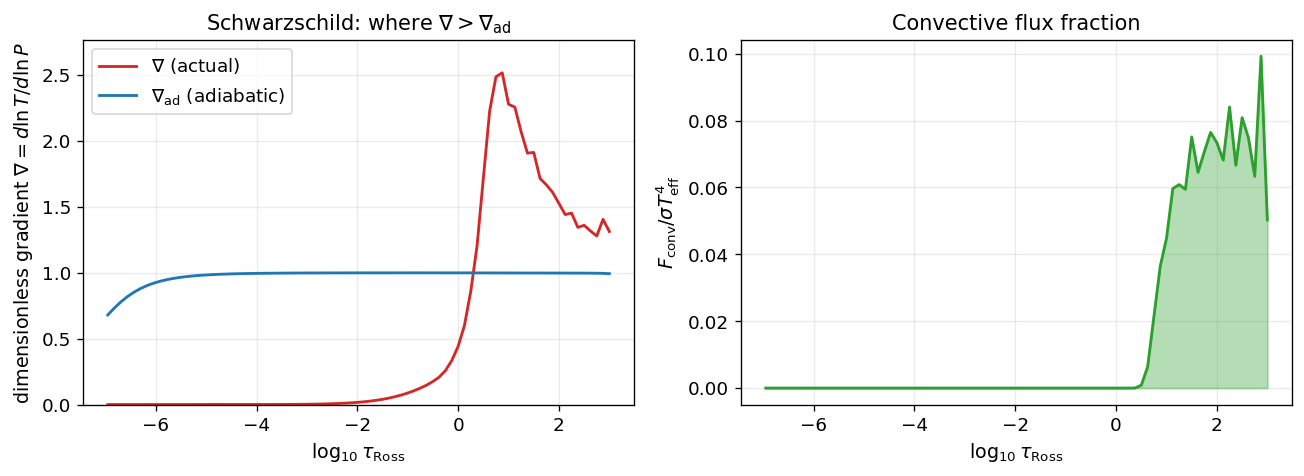

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))
x = np.log10(tauros)

# left: the two dimensionless gradients themselves -- convection switches on where the
# actual gradient (C3) climbs above the adiabatic one (C0); the gap between them is Delta
ax[0].plot(x, cv["dltdlp"], color="C3", lw=1.7, label=r"$\nabla$ (actual)")
ax[0].plot(x, cv["grdadb"], color="C0", lw=1.7, label=r"$\nabla_{\rm ad}$ (adiabatic)")
ax[0].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$"); ax[0].set_ylabel(r"dimensionless gradient $\nabla = d\ln T/d\ln P$")
ax[0].set_title("Schwarzschild: where $\\nabla>\\nabla_{\\rm ad}$"); ax[0].legend(loc="upper left")
ax[0].set_ylim(0, max(0.6, np.nanmax(cv["dltdlp"][np.isfinite(cv["dltdlp"])])*1.1))

# right: the convective flux as a fraction of the total flux, F_conv / sigma Teff^4.
# FOURPI * flux = 4 pi H = sigma Teff^4, so dividing by it gives the flux fraction directly
ax[1].fill_between(x, 0, cv["flxcnv"]/(FOURPI*flux), color="C2", alpha=0.35)
ax[1].plot(x, cv["flxcnv"]/(FOURPI*flux), color="C2", lw=1.7)
ax[1].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$"); ax[1].set_ylabel(r"$F_{\rm conv}/\sigma T_{\rm eff}^4$")
ax[1].set_title("Convective flux fraction")
fig.tight_layout(); plt.show()

## The temperature correction, now with convection

The temperature correction of Lecture 10 — $T_1 = \Delta T_{\rm flux} + \Delta T_\Lambda + \Delta T_{\rm surf}$ — gains the convective flux in three places. (1) The **flux error** it drives toward zero is now the *total* flux $H + F_{\rm conv}/4\pi$ minus the target, not the radiative flux alone. (2) The Avrett–Krook denominator picks up a **convective-efficiency** term `ddel` (how strongly $F_{\rm conv}$ responds to a temperature change), so the correction knows that in a convective layer some of the flux adjustment comes for free from convection — without it, TCORR would over-correct the temperature and the iteration would oscillate. (3) The convective flux is **smoothed** with a 1–2–1 filter and its top two layers explicitly re-zeroed before use, since the raw layer-by-layer flux is noisy. (`CONVEC` already forced the top layers to zero, but the 1–2–1 spatial filter would otherwise bleed deep convective flux upward into the purely radiative boundary layers, so they must be re-zeroed after smoothing.) Note also that TCORR uses *both* convective-flux arrays: the physically used flux `flxcnv` (zeroed in the top `NCONV` layers and smoothed) drives the total-flux defect, while ATLAS retains the **pre-patch array `flxcnv0`** — the convective flux before the top layers were zeroed — to gate parts of the temperature-correction response. Everything else — the local-$\Lambda$ surface term, the surface-boundary term, the monotonicity clamp, and the hydrostatic density correction via `TTAUP` — is carried over from Lecture 10 unchanged. We are at the converged fixed point (`iter_index = 1`), so the damping/acceleration logic is skipped.

In [39]:
def ttaup(t, tau, prad, grav, rfun):
    """Hydrostatic re-integration on a tau grid, opacity from ROSSTAB (Lecture 10 TTAUP).
    Predictor-corrector in log-pressure: integrate dP/dtau = g/kappa down the column."""
    nl = t.size; abstd=np.zeros(nl); ptot=np.zeros(nl); pgas=np.zeros(nl)
    dlg = np.log(max(float(tau[1]/max(tau[0],1e-300)),1e-300)) if nl > 1 else 0.0   # log tau step
    plog1=plog2=plog3=plog4=0.0; dplog1=dplog2=dplog3=0.0                            # history for the predictor
    abstd[0] = min(0.1, grav*tau[0]/max(prad[0],1e-300)/2.0) if prad[0] > 0.0 else 0.1   # surface opacity guess
    for j in range(nl):
        if j == 0: plog = np.log(max(grav/max(abstd[0],1e-300)*tau[0],1e-300))       # top: P = g tau / kappa
        elif j <= 3: plog = plog1 + dplog1                                            # low-order predictor
        else: plog = (3.0*plog4 + 8.0*dplog1 - 4.0*dplog2 + 8.0*dplog3)/3.0           # high-order predictor
        error=1.0; dplog=0.0; itn=1
        while True:                                                                   # corrector iteration
            plog = min(plog, 709.78); ptot[j] = np.exp(plog)                          # total pressure
            pgas[j] = ptot[j] + (prad[0]-prad[j])                                     # subtract radiation pressure
            if pgas[j] <= 0.0: pgas[j]=1e-30; abstd[j]=0.1; break
            abstd[j] = rfun(float(t[j]), float(pgas[j]))                              # ROSSTAB opacity at (T, Pgas)
            dplog = grav/max(abstd[j],1e-300)*tau[j]/max(ptot[j],1e-300)*dlg; itn += 1 # d(log P)/d(log tau)
            if itn > 1000 or error <= 5.0e-5: break
            if j == 0: pnew = np.log(max(grav/max(abstd[j],1e-300)*tau[j],1e-300))
            elif j <= 3: pnew = (plog + 2.0*plog1 + dplog + dplog1)/3.0               # low-order corrector
            else: pnew = (126.0*plog1 - 14.0*plog3 + 9.0*plog4 + 42.0*dplog + 108.0*dplog1 - 54.0*dplog2 + 24.0*dplog3)/121.0
            error = abs(pnew-plog); plog = 0.5*(pnew+plog)                            # damped update
        plog4=plog3; plog3=plog2; plog2=plog1; plog1=plog; dplog3=dplog2; dplog2=dplog1; dplog1=dplog  # shift history
    return abstd, ptot, pgas

`tcorr_mode3` is the Lecture 10 temperature correction with convection folded in. It assembles the same three terms — $T_1 = \Delta T_{\rm flux} + \Delta T_\Lambda + \Delta T_{\rm surf}$ — but the convective flux enters in three places: the defect it drives toward zero is now the *total* flux $H + F_{\rm conv}/4\pi - H_{\rm target}$, the Avrett–Krook denominator picks up the convective-efficiency response `ddel`, and $F_{\rm conv}$ is 1–2–1 smoothed (with its top two layers re-zeroed) first. It then closes the iteration with the density correction by running `ttaup` above (the hydrostatic integration that solves $dP/d\tau = g/\kappa$ down the column) on $T$ and on $T+T_1$ and differencing the pressures.

The routine has six separable blocks, which we extract into named helpers first — the convective-flux smoothing, the per-layer Avrett–Krook integrand, the local-$\Lambda$ surface term, the flux-driven term, the surface-boundary term, and the density correction — so the main `tcorr_mode3` body reads as a short sequence of named steps. Each helper is moved out verbatim and called at the same point with the same inputs and outputs, so the arithmetic is bit-for-bit unchanged.

**Step 1 — smooth the convective flux.** The raw layer-by-layer $F_{\rm conv}$ is noisy, so before it enters the correction it is run through a 1–2–1 spatial filter, with the top two layers explicitly re-zeroed first (otherwise the filter would bleed deep convective flux up into the radiative boundary layers). `smooth_convective_flux` does exactly that and returns the smoothed copy `cnvflx`.

In [40]:
def smooth_convective_flux(flxcnv, nl):
    """1-2-1 smoothing of the convective flux with the top two layers re-zeroed (Lecture 11 TCORR)."""
    cnvflx = flxcnv.copy(); cnvflx[0] = 0.0                            # smooth the convective flux: zero top two,
    if nl >= 2: cnvflx[1] = 0.0
    if nl >= 3:
        ccc = cnvflx.copy()
        for j in range(1, nl-1): ccc[j] = 0.25*cnvflx[j-1] + 0.5*cnvflx[j] + 0.25*cnvflx[j+1]   # 1-2-1 filter
        ccc[-1] = 0.25*cnvflx[-3] + 0.25*cnvflx[-2] + 0.5*cnvflx[-1]
        for j in range(1, nl-1): cnvflx[j] = ccc[j]
        cnvflx[-1] = ccc[-1]
    return cnvflx

**Step 2 — the Avrett–Krook integrand.** Per layer, this builds the integrand `codrhx` whose exponential integral is the Avrett–Krook integrating factor, and alongside it the convective-efficiency response `ddel = dF_conv/dT`. In a convective layer (`cnvflx>0` and `flxcnv0>0`) it re-forms the velocity, flux, and optical-thickness factors from `CONVEC` to get `ddel`; the numerator carries the convective flux only where it is more than 0.1% of the radiative flux, and the denominator is the total-flux response (radiative plus the convective `ddel` term). The top two layers of `codrhx` are zeroed. `ak_integrand` returns `(codrhx, ddel)`.

In [41]:
def ak_integrand(nl, T, flxrad, rdabh_eff, dtdrhx, ddlt, cnvflx, flxcnv0,
                 dltdlp, grdadb, hscale, dlrdlt, heatcp, ptc, rhc, abross, mixlth):
    """Per-layer Avrett-Krook integrand codrhx and convective-efficiency response ddel (Lecture 11 TCORR)."""
    codrhx = np.zeros(nl); ddel = np.zeros(nl)
    for j in range(nl):                                               # per layer: AK integrand + convective ddel
        delv = 1.0; d = 0.0
        if cnvflx[j] > 0.0 and flxcnv0[j] > 0.0:                       # convective-efficiency factor ddel
            delv = dltdlp[j] - grdadb[j]                               # superadiabaticity at this layer
            vco = 0.5*mixlth*np.sqrt(max(-0.5*ptc[j]/max(rhc[j],1e-300)*dlrdlt[j], 0.0))   # velocity scale
            fluxco = 0.5*rhc[j]*heatcp[j]*T[j]*mixlth/FOURPI           # flux scale
            if mixlth > 0.0 and vco > 0.0:                            # radiative-loss parameter d
                d = 8.0*SIGMA*T[j]**4/np.maximum(abross[j]*hscale[j]*rhc[j],1e-300)/np.maximum(fluxco*FOURPI,1e-300)/vco
            taub = abross[j]*rhc[j]*mixlth*hscale[j]; d = d*taub*taub/(2.0+taub*taub); d = d*d/2.0   # optical-thickness
            ddel[j] = (1.0 + d/_nz_signed(float(d+delv)))/_nz_signed(float(delv))   # dF_conv/dT response
        cnvfl = 0.0
        if flxrad[j] > 0.0 and cnvflx[j]/flxrad[j] > 1.0e-3 and flxcnv0[j]/flxrad[j] > 1.0e-3:
            cnvfl = cnvflx[j]                                         # convective flux only where it matters (>0.1%)
        dd = _nz_signed(float(d+delv)); ds = _nz_signed(float(delv))
        num = rdabh_eff[j] + cnvfl*(dtdrhx[j]/max(T[j],1e-300)*(1.0-9.0*d/dd) + 1.5*ddlt[j]/ds*(1.0+d/dd))
        den = flxrad[j] + cnvflx[j]*1.5*dltdlp[j]*ddel[j]             # total-flux denominator (rad + conv response)
        codrhx[j] = num/_nz_signed(float(den))
    codrhx[0] = 0.0
    if nl >= 2: codrhx[1] = 0.0
    return codrhx, ddel

**Step 3 — the local-$\Lambda$ surface term.** This is the Lecture 10 surface correction: per layer it forms the flux-derivative driver `flxdrv` (switching to the net-heating form $\kappa(J-S)$ where the convective fraction is negligible), divides by the $\Lambda$-diagonal `rdiagj`, restricts the term to the optically-thin radiative surface, halves the five layers above any non-surface layer, and clamps the result to $\pm T_{\rm eff}/25$. `lambda_surface_term` returns the array `dtlamb`.

In [42]:
def lambda_surface_term(nl, tauros, abross, flxrad, rjmins, rdiagj, flxerr, cnvflx, flux, teff):
    """Local-Lambda surface temperature term dtlamb (Lecture 10 TCORR, convection-gated)."""
    flxdrv = deriv(tauros, flxerr); dtlamb = np.zeros(nl); teff25 = teff/25.0
    for j in range(nl):                                               # local-Lambda surface term (Lecture 10)
        ratio = cnvflx[j]/np.maximum(flxrad[j], 1e-300)
        if ratio < 1.0e-5:
            flxdrv[j] = rjmins[j]/np.maximum(abross[j],1e-300)/np.maximum(flux,1e-300)*100.0
        denom = rdiagj[j] if abs(rdiagj[j]) > 1e-300 else np.sign(rdiagj[j])*1e-300
        dtlamb[j] = -flxdrv[j]*flux/100.0/denom*abross[j]
        if not (ratio < 1.0e-5 and tauros[j] < 1.0):
            dtlamb[j] = 0.0
            for k in range(1, 6):
                if j-k >= 0: dtlamb[j-k] *= 0.5
        dtlamb[j] = float(np.clip(dtlamb[j], -teff25, teff25))
    return dtlamb

**Step 4 — the density (DRHOX) correction.** Once $T_1$ is known, the column mass must follow. This remaps $T$, $T+T_1$, and $P_{\rm rad}$ onto the fixed standard optical-depth grid `taustd`, runs the hydrostatic `ttaup` integration twice (on $T$ and on $T+T_1$), and differences the resulting total pressures to get the fractional pressure change, mapped back to the Rosseland grid as `rrr` (the fractional $\Delta\rho x$). `drhox_density_correction` returns `rrr`.

In [43]:
def drhox_density_correction(tauros, T, t1, prad, grav, rosstab, nl, steplg, tau1lg):
    """Density correction DRHOX: hydrostatic re-integration on T and T+t1, differenced (Lecture 10 TCORR)."""
    taustd = 10.0**(tau1lg + np.arange(nl)*steplg); rfun = rosstab.eval   # DRHOX: re-run TTAUP on T and T+t1
    tnew1, _ = map1(tauros, T, taustd); prdnew, _ = map1(tauros, prad, taustd)   # T and P_rad on the std grid
    _a1, ptot1, _ = ttaup(tnew1, taustd, prdnew, grav, rfun)          # hydrostatic pressure for T
    tnew2, _ = map1(tauros, T+t1, taustd)
    _a2, ptot2, _ = ttaup(tnew2, taustd, prdnew, grav, rfun)          # hydrostatic pressure for T+T1
    ppp = (ptot2-ptot1)/np.maximum(ptot1, 1e-300); rrr, _ = map1(taustd, ppp, tauros)   # fractional dP -> dRHOX
    return rrr

**Step 5 — the flux-driven term.** The heart of the correction: the Avrett–Krook integrating factor $g = \exp\int\texttt{codrhx}\,d(\rho x)$, the total-flux defect $H + F_{\rm conv} - H_{\rm target}$ divided by the (signed-floored) total-flux denominator and weighted by $g$, integrated over $\tau_{\rm Ross}$ and divided back out to give the optical-depth shift $\Delta\tau$, clamped for stability, and converted into the temperature term $\Delta T_{\rm flux} = -\Delta\tau\,(dT/d\rho x)/\kappa$. `flux_driven_term` returns `dtflux`.

In [44]:
def flux_driven_term(rhox, tauros, codrhx, ddel, flxrad, cnvflx, dltdlp, flux, dtdrhx, abross):
    """The Avrett-Krook flux-driven temperature term dtflux (Lecture 10 + CONVEC TCORR)."""
    g = np.exp(integ(rhox, codrhx, 0.0))                              # Avrett-Krook integrating factor
    gfden = flxrad + cnvflx*1.5*dltdlp*ddel
    gfden_s = np.where(np.abs(gfden) >= 1e-300, gfden, np.where(gfden >= 0.0, 1e-300, -1e-300))
    gflux = g*(flxrad + cnvflx - flux)/gfden_s                         # total-flux defect drives Avrett-Krook
    dtau = integ(tauros, gflux, 0.0)/np.maximum(g, 1e-300)
    dtau = np.maximum(-tauros/3.0, np.minimum(tauros/3.0, dtau))       # stability clamp on the tau shift
    dtflux = -dtau*dtdrhx/np.maximum(abross, 1e-300)
    return dtflux

**Step 6 — the surface-boundary term.** A single constant per column, set by the surface flux defect $(H_{\rm target}-H_0)/H_{\rm target}$ and clamped to $\pm T_{\rm eff}/25$, with the depth-averaged part of the flux+$\Lambda$ terms (`tav`, sampled at $\tau_{\rm Ross}=0.1$ and $2$) subtracted off so the boundary term does not double-count what the depth integral already carries. `surface_boundary_term` returns the constant array `dtsurf`.

In [45]:
def surface_boundary_term(nl, teff, flux, flxrad, T, tauros, dtflux, dtlamb):
    """Surface-boundary temperature term dtsurf, with the depth-averaged part removed (Lecture 10 TCORR)."""
    teff25 = teff/25.0
    dtsur = float(np.clip((flux-flxrad[0])/np.maximum(flux,1e-300)*0.25*T[0], -teff25, teff25))  # surface term
    tinteg = integ(tauros, dtflux+dtlamb, 0.0)
    tav = (map1_scalar(tauros, tinteg, 2.0) - map1_scalar(tauros, tinteg, 0.1))/2.0
    if dtsur*tav <= 0.0: tav = 0.0
    if abs(tav) > abs(dtsur): tav = dtsur
    dtsur = dtsur - tav; dtsurf = np.full(nl, dtsur)
    return dtsurf

**The assembled correction.** With the six helpers in place, `tcorr_mode3` reads as a short sequence: unpack the `CONVEC` arrays, smooth the convective flux, build the Avrett–Krook integrand, form the flux-driven term $\Delta T_{\rm flux}$, add the surface $\Lambda$ term and the surface-boundary term, clamp for monotonicity, and finally run the density correction. The same float operations execute in the same order as before.

In [46]:
def tcorr_mode3(T, rhox, tauros, abross, flxrad, rjmins, rdabh, rdiagj, flux, teff, prad, grav,
                rosstab, cv, mixlth=1.25, steplg=0.125, tau1lg=-6.875):
    """ATLAS TCORR mode 3 with convection: T1 = dtflux + dtlamb + dtsurf, plus DRHOX (Lecture 10 + CONVEC)."""
    nl = T.size

    # the depth derivatives and the CONVEC arrays the correction reads
    dtdrhx = deriv(rhox, T); dabros = deriv(rhox, abross)             # dT/d(rhox) and d(kappa)/d(rhox)
    flxcnv=cv["flxcnv"]; flxcnv0=cv["flxcnv0"]; dltdlp=cv["dltdlp"]; grdadb=cv["grdadb"]   # unpack CONVEC arrays
    hscale=cv["hscale"]; dlrdlt=cv["dlrdlt"]; heatcp=cv["heatcp"]; ptc=cv["ptotal"]; rhc=cv["rho"]
    ddlt = deriv(rhox, dltdlp)                                        # gradient of the actual gradient

    # Step 1-2: smooth the convective flux, then build the Avrett-Krook integrand
    cnvflx = smooth_convective_flux(flxcnv, nl)                       # 1-2-1 smoothing, top two re-zeroed
    rdabh_eff = rdabh - flxrad*dabros/np.maximum(abross, 1e-300)      # opacity-gradient term in the AK denominator
    codrhx, ddel = ak_integrand(nl, T, flxrad, rdabh_eff, dtdrhx, ddlt, cnvflx, flxcnv0,
                                dltdlp, grdadb, hscale, dlrdlt, heatcp, ptc, rhc, abross, mixlth)

    # Step 3-6: the three temperature terms -- flux-driven, surface Lambda, surface boundary
    dtflux = flux_driven_term(rhox, tauros, codrhx, ddel, flxrad, cnvflx, dltdlp, flux, dtdrhx, abross)
    flxerr = (flxrad + cnvflx - flux)/np.maximum(flux, 1e-300)*100.0   # percent TOTAL-flux error
    dtlamb = lambda_surface_term(nl, tauros, abross, flxrad, rjmins, rdiagj, flxerr, cnvflx, flux, teff)
    dtsurf = surface_boundary_term(nl, teff, flux, flxrad, T, tauros, dtflux, dtlamb)

    # assemble T1 = dtflux + dtlamb + dtsurf and enforce monotonicity with depth
    dtflux = np.nan_to_num(dtflux); dtlamb = np.nan_to_num(dtlamb); dtsurf = np.nan_to_num(dtsurf)   # sanitize
    t1 = dtflux + dtlamb + dtsurf                                     # total temperature correction
    tnew = np.maximum(np.where(np.isfinite(T+t1), T+t1, T), 1.0)       # iter 1: damping skipped
    for i in range(1, nl):                                            # monotonicity: T increasing with depth
        j = nl-1-i; tnew[j] = np.fmin(tnew[j], tnew[j+1]-1.0)
        if not np.isfinite(tnew[j]): tnew[j] = max(T[j], 1.0)

    # close the iteration with the hydrostatic density (DRHOX) correction
    rrr = drhox_density_correction(tauros, T, t1, prad, grav, rosstab, nl, steplg, tau1lg)   # DRHOX
    return dict(t1=t1, dtflux=dtflux, dtlamb=dtlamb, flxerr=flxerr, cnvflx=cnvflx,
                tnew=tnew, rhox_new=rhox + rrr*rhox)

res = tcorr_mode3(T, rhox, tauros, abross, flxrad, rjmins, rdabh, rdiagj, flux, TEFF, prad, GRAV, rosstab, cv)
print(f"temperature correction T1 spans {res['t1'].min():+.3e} to {res['t1'].max():+.3e} K")

temperature correction T1 spans -1.031e+01 to +6.247e+01 K


## Closing the iteration and the fixed-point benchmark

The iteration closes exactly as in Lecture 10: remap the corrected temperature $T+T_1$ and column mass $\rho x + \Delta\rho x$ from the Rosseland grid onto the fixed standard optical-depth grid `taustd`. We then benchmark in two complementary ways. The **precision** benchmark compares our single step to *pykurucz's own single step from the same converged input* — this isolates the fidelity of our engines from a subtlety about what "converged" means. The **self-consistency** benchmark compares our step to the converged model itself: because the model is converged, one step barely moves it.

In [47]:
taustd = 10.0**(-6.875 + np.arange(n)*0.125)
T_out,    _ = map1(tauros, res["tnew"],     taustd)   # corrected T,    remapped to the standard grid
rhox_out, _ = map1(tauros, res["rhox_new"], taustd)   # corrected RHOX, remapped to the standard grid

def rel(a, b):
    b = np.asarray(b, float); a = np.asarray(a, float)
    m = np.abs(b) > 0; r = np.zeros_like(b); r[m] = np.abs(a[m]-b[m])/np.abs(b[m]); return r

# PRECISION benchmark: our single step vs pykurucz's SAME single step (engine fidelity)
rT = rel(T_out,    REF["T_step"]).max()
rX = rel(rhox_out, REF["rhox_step"]).max()
# the NEW convection physics, vs the reference CONVEC arrays
rF = rel(cv["flxcnv"], REF["flxcnv_ref"]).max()
rG = rel(cv["grdadb"], REF["grdadb_ref"]).max()
# self-consistency: our step vs the converged model (one step ~ no-op)
rT_self = np.median(rel(T_out, REF["T_converged"]))
print(f"CONVEC: FLXCNV max|rel| = {rF:.2e}   grdadb max|rel| = {rG:.2e}")
print(f"one-step vs pykurucz step: T = {rT:.2e}   RHOX = {rX:.2e}")
print(f"self-consistency vs converged model: median dT/T = {rT_self:.2e}")

CONVEC: FLXCNV max|rel| = 2.39e-10   grdadb max|rel| = 2.51e-14
one-step vs pykurucz step: T = 1.57e-09   RHOX = 2.59e-08
self-consistency vs converged model: median dT/T = 4.98e-06


## The benchmark

The new convection physics — the convective flux `flxcnv` and the gradients — is pure float64: the gradients reach genuine **float64 machine precision** ($\sim10^{-16}$), and the convective flux matches the production code to $\sim10^{-10}$. The full step — temperature *and* column mass — reproduces pykurucz's single step from the same converged input to the **precision floor of the reference** (T $\sim10^{-9}$, column mass $\sim10^{-8}$); that floor is set by the float32 $\Lambda$-iteration inside JOSH (the one single-precision step in the whole pipeline, Lecture 8), which jitters the flux at the ULP level and averages out — single-precision-level agreement, not float64 machine epsilon.

A word on the second number we printed. Comparing our step instead to the **converged model itself** gives a median $\sim10^{-6}$ in the deep temperature — but the *top* layers and the column mass differ at the $\sim10^{-3}$ level. That is not an error: it is what "converged" means. ATLAS stops when the **deep-layer** $\max|\Delta T/T| < 10^{-4}$; one more step is *not* an exact no-op everywhere — the thin upper layers and the density keep drifting at the $10^{-3}$ level, which is precisely why `checkconv` looks only at the deep layers. The machine-precision claim is the engine-fidelity comparison (vs the same single step); the self-consistency comparison confirms the model sits at the convergence criterion.

In [48]:
print("="*64)
print("LECTURE 11 BENCHMARK  (one iteration from the converged solar model)")
print("="*64)
print(f"  FLXCNV (NEW: convection)  : max|rel| = {rF:.2e}   <- float64 convection")
print(f"  one-step T   (vs pykurucz): max|rel| = {rT:.2e}   <- reference precision floor")
print(f"  one-step RHOX(vs pykurucz): max|rel| = {rX:.2e}   <- reference precision floor")
ok = (rF < 1e-6) and (rT < 1e-6) and (rX < 1e-6)
print("  PASS" if ok else "  FAIL")
print("="*64)

LECTURE 11 BENCHMARK  (one iteration from the converged solar model)
  FLXCNV (NEW: convection)  : max|rel| = 2.39e-10   <- float64 convection
  one-step T   (vs pykurucz): max|rel| = 1.57e-09   <- reference precision floor
  one-step RHOX(vs pykurucz): max|rel| = 2.59e-08   <- reference precision floor
  PASS


### The converged model and its flux constancy

Two pictures close the loop. The left panel plots the **convergence history** — the deep-layer $\max|\Delta T/T|$ falling from order unity at the grey start to below $10^{-4}$ over the 28 iterations the production run took, while the all-layer metric stalls higher because the thin top layers settle last. The right panel is the payoff: the **total** flux (radiative + convective) across the converged model, flat at the target $\sigma T_{\rm eff}^4$ — radiation carries it in the upper photosphere, convection takes over in the deep interior, and together they hold the flux constant. *That* constancy is what "converged" means.

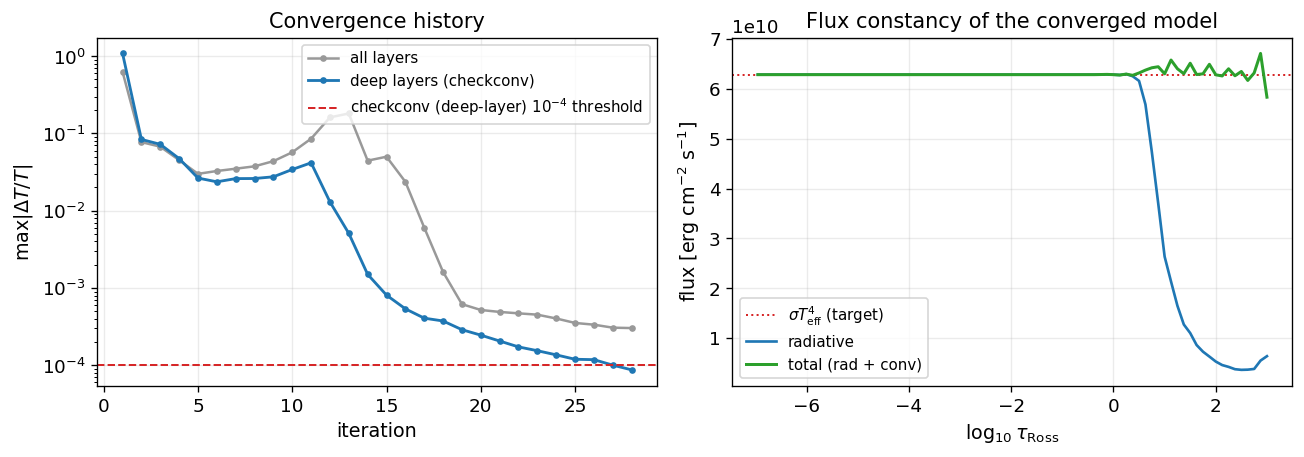

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))
it = np.arange(1, REF["dlnt_history"].size + 1)
ax[0].semilogy(it, REF["dtmax_history"], color="0.6", lw=1.5, marker="o", ms=3, label="all layers")
ax[0].semilogy(it, REF["dlnt_history"],  color="C0",  lw=1.7, marker="o", ms=3, label="deep layers (checkconv)")
ax[0].axhline(1e-4, color="C3", ls="--", lw=1.2, label=r"checkconv (deep-layer) $10^{-4}$ threshold")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel(r"$\max|\Delta T/T|$")
ax[0].set_title("Convergence history"); ax[0].legend(loc="upper right", fontsize=9)

Ftot = (flxrad + res["cnvflx"]) * FOURPI                    # total flux 4 pi (H + F_conv/4pi)
ax[1].axhline(SIGMA*TEFF**4, color="C3", ls=":", lw=1.2, label=r"$\sigma T_{\rm eff}^4$ (target)")
ax[1].plot(np.log10(tauros), flxrad*FOURPI,      color="C0", lw=1.6, label="radiative")
ax[1].plot(np.log10(tauros), Ftot,               color="C2", lw=1.8, label="total (rad + conv)")
ax[1].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$"); ax[1].set_ylabel(r"flux [erg cm$^{-2}$ s$^{-1}$]")
ax[1].set_title("Flux constancy of the converged model"); ax[1].legend(loc="lower left", fontsize=9)
fig.tight_layout(); plt.show()

## The milestone: from $(T_{\rm eff}, \log g)$ to a model atmosphere

This lecture closes the loop the very first lecture opened. In Lectures 1–8 we *took the atmosphere as given* — a table of $T(\tau)$, $P(\tau)$, $\rho(\tau)$ shipped with the book — and used it to compute opacities and an emergent spectrum. We never built that table; we borrowed it. From Lecture 9 onward we earned it: hydrostatic equilibrium fixed the pressure structure (Lecture 9), the temperature correction fixed the temperature for flux constancy (Lecture 10), and now convection plus the convergence loop produce a **self-consistent model from a grey start**. In the full ATLAS/pykurucz pipeline this needs nothing but $T_{\rm eff}$, $\log g$, and the composition; in this lecture we benchmarked *one* iteration of that loop, taking the per-frequency opacity, the JOSH operator tables, and the EOS atomic data as supplied reference inputs — but recomputing the physics that acts on them (the equation of state, the radiation pressure, the convection, the temperature correction) from scratch.

One honest qualifier before we celebrate. The model we converge here is **continuum-only**: in the frequency sweep the only opacity is the continuum of Lecture 3, with the millions of spectral lines switched off. That is a deliberate teaching simplification — it needs no multi-gigabyte line list, so the whole loop stays reproducible with NumPy alone — but it is *not yet the real Sun*. A real model atmosphere is **line-blanketed**, and switching the lines on reshapes the temperature structure (back-warming the deep layers, cooling the surface). So this is the converged *continuum* atmosphere: the convergence machinery, proven to a fixed point, on the simplest opacity. Building the genuinely line-blanketed model that reaches the real Sun is the work of **Part VI** — the true finale, where this same engine runs with the blanket switched on.

The path is complete in outline: **$(T_{\rm eff}, \log g, {\rm composition}) \to$ grey start (Lecture 9) $\to$ {EOS, opacity, Rosseland mean, JOSH flux, convection, temperature correction}, iterated to flux constancy $\to$ the converged continuum atmosphere $\to$ the emergent spectrum (Lectures 1–8)**. A star's few numbers become its entire structure and its spectrum, from first principles and benchmarked at every step to pykurucz's reference precision floor — with the line blanket the one physical ingredient still held back, switched on in Part VI.

## What comes next: molecules, the end-to-end spectrum, and the real line-blanketed Sun

The model we just converged is **continuum-only** — deliberately, so it needs no line data and stays reproducible with NumPy alone. A real model is **line-blanketed**: the millions of spectral lines (the atomic forest of Lectures 4–6) block radiation across many frequency intervals, redistribute the flux, and reshape the temperature structure — heating the deeper layers (back-warming) while cooling the outer ones. Switching them on changes nothing in the *machinery* of this lecture — the frequency sweep simply carries line opacity alongside the continuum, and the correction and convection are untouched — but it needs the large line lists and one deposit kernel that **Part VI** introduces. That is the debt this lecture leaves open, and the book pays it in full there.

Three threads run from here. For **cool stars** there is one more ingredient: **molecules**. Below about 4000 K, molecules like TiO, H$_2$O, and CO form in vast numbers, dominate the opacity, and carve the broad molecular bands that define an M dwarf's spectrum. Their equilibrium abundances feed back into the equation of state and the opacity, so the convergence loop must include molecular chemistry. That is the subject of **Lecture 12 (Molecular Equilibrium & Molecular Bands)** and **Lecture 13 (Molecular Chemistry: the Coupled Equilibrium and Continuous Opacity)**.

The book then completes the **synthesis** half — given an atmosphere, the emergent spectrum — in **Lecture 14 (A Spectrum from Stellar Parameters, End to End)**, which assembles the whole opacity-and-transfer stack (EOS, continuum, atomic and hydrogen and helium lines, molecular bands, JOSH transfer) and runs it across four stars spanning the HR diagram, computing every spectrum from scratch.

And the book closes by finishing the **atmosphere** half this very lecture began: **Part VI (Lectures 15–16)** switches the line blanket on, builds the per-iteration equation of state from scratch, and reruns *this* convergence engine — unchanged — until it lands on the **real, line-blanketed Sun**. The continuum-only model we just converged is the scaffold; Part VI is where it becomes the true model atmosphere.

## Synthesis

Lecture 10 built one radiative-equilibrium correction step; this lecture turned it into a converged *continuum* model by adding the two missing pieces (the line-blanketed model that reaches the real Sun is Part VI). **Convection**: in the deep photosphere of a cool star the radiative gradient exceeds the adiabatic gradient (the Schwarzschild criterion), the gas becomes unstable, and rising/falling parcels carry part of the flux. We implemented Kurucz's mixing-length `CONVEC` — the adiabatic gradient $\nabla_{\rm ad}$ and superadiabaticity $\Delta=\nabla-\nabla_{\rm ad}$, with the thermodynamic derivatives obtained by re-running the equation of state from scratch (the Saha/Boltzmann ionization and charge-balance electron solve of Lecture 2) at $T,P\pm0.1\%$, and a 30-iteration inner loop for the convective flux $F_{\rm conv}$ using the optical-thickness efficiency $\tau_b^2/(2+\tau_b^2)$ — and saw it is zero in the line-forming layers but carries much of the deep flux. We also added the optional **overshoot** extension, the geometric smear that lets a parcel coast past the Schwarzschild boundary, reproducing ATLAS's `OVERWT` blend. That flux feeds the temperature correction in three places (the total-flux defect, the convective-efficiency denominator, and a smoothing). **Convergence**: iterating the corrected EOS, opacity, fluxes, convection, and temperature drives the model to flux constancy, measured as $\max|\Delta T/T|<10^{-4}$ over the deep layers; the solar model took 28 iterations from a grey start. We verified the converged model is a fixed point of our from-scratch pipeline: one from-scratch iteration reproduces pykurucz's own single step from the converged model to the **reference precision floor** — the convective flux and the gradients in float64, the temperature and column mass to the single-precision floor JOSH's one float32 inner sweep sets.

## Summary

- The deep photosphere **convects** where the actual gradient exceeds the adiabatic one, $\nabla > \nabla_{\rm ad}$ (the **Schwarzschild criterion**); the excess $\Delta = \nabla - \nabla_{\rm ad}$ is the superadiabaticity. In the Sun this happens below the visible surface, driven by hydrogen ionization; the **line-forming layers stay radiative**.
- **Mixing-length theory** (`CONVEC`) carries a parcel one mixing length $\ell = \alpha_{\rm ML} H_P$ ($\alpha_{\rm ML}=1.25$) and computes the convective flux $F_{\rm conv}$ from $\Delta$, the convective velocity, and the optical-thickness efficiency $\tau_b^2/(2+\tau_b^2)$ ($\tau_b = \kappa\rho\ell$). The thermodynamic derivatives $\partial E/\partial T$, $\partial\rho/\partial T$, $\partial E/\partial P$, $\partial\rho/\partial P$ come from **finite differences of the equation of state**, which we re-run from scratch (Saha/Boltzmann + the charge-balance electron solve of Lecture 2) at $T,P\pm0.1\%$; the top `NCONV=36` layers are forced radiative.
- **Convective overshoot** (`OVERWT`) extends the flux past the Schwarzschild boundary by window-averaging $F_{\rm conv}$ over a geometric height window and taking $\max(F_{\rm conv}^{(0)},F_{\rm conv}^{(1)})$. The solar model runs with it off, but the blend is reproduced bit-exactly.
- The convective flux enters the **temperature correction** through the total-flux defect $H + F_{\rm conv}/4\pi - H_{\rm target}$, a convective-efficiency term in the Avrett–Krook denominator, and a 1–2–1 smoothing of $F_{\rm conv}$.
- The **radiation pressure** $P_{\rm rad} = \frac{4\pi}{c}\int\!\!\int\kappa_\nu H_\nu\,d\nu\,d(\rho x)$ (ATLAS `RADIAP`) is now **computed** from the per-frequency flux of the sweep — feeding the convective $dP/dT$ term ($P_{\rm radk} = P_{\rm rad} + $ a scalar surface K-integral) and the hydrostatic density correction — rather than read from the reference. It matches the production code to the float32-JOSH floor ($\sim10^{-8}$).
- **Convergence** means flux constancy, tested as $\max|\Delta T/T| < 10^{-4}$ over the **deep layers** (ATLAS `checkconv`, Fortran layers 40–75); the upper layers settle last and are excluded. The solar continuum-only model converges in **28 iterations** from the grey start.
- The converged atmosphere is a **fixed point**: one from-scratch iteration {opacity, JOSH, Rosseland mean, convection, temperature correction} reproduces pykurucz's own single step to the **reference precision floor** — the gradients in genuine float64 ($\sim10^{-14}$) and the convective flux ($\sim10^{-10}$), the temperature ($\sim10^{-9}$) and column mass ($\sim10^{-8}$) to the single-precision floor of JOSH's one float32 inner sweep. "Converged" means the deep-layer $\max|\Delta T/T|<10^{-4}$, not that one step is an exact no-op everywhere.
- This closes the loop the book opened — in outline: from $(T_{\rm eff}, \log g, {\rm composition})$ we now build the **converged continuum model atmosphere**, the structure Lectures 1–8 took as given. The one physical ingredient still held back is the **line blanket**; switching it on and reaching the real Sun's model atmosphere is the work of **Part VI (Lectures 15–16)**, which reruns this very convergence engine, unchanged, with the lines on.

## Practice exercises

**1. The Schwarzschild criterion, layer by layer.** Print $\nabla$, $\nabla_{\rm ad}$, and $\Delta = \nabla - \nabla_{\rm ad}$ versus $\log\tau_{\rm Ross}$ and find the first layer where $\Delta$ turns positive. Confirm it lies *below* the line-forming region ($\tau_{\rm Ross}\sim1$). Why does hydrogen ionization both flatten $\nabla_{\rm ad}$ and (via the opacity) steepen $\nabla$, so that the two conspire to make $\Delta > 0$?

**2. The efficiency factor.** In the inner loop, replace the optical-thickness factor $\tau_b^2/(2+\tau_b^2)$ with $1$ (an infinitely efficient cell) and recompute the convective flux. Where does it change most, and why? Explain physically why an optically *thin* cell ($\tau_b\ll1$) radiates away its heat before delivering it and so carries little flux.

**3. The mixing length.** Re-run `convec` with $\alpha_{\rm ML} = 0.5$ and $2.0$ and compare the peak convective flux fraction and the depth where convection switches on. The mixing length is the one free parameter of the theory — which observable features of a model atmosphere is it tuned against?

**4. Reading the convergence history.** From `dlnt_history`, estimate the *convergence rate* (the ratio of successive deep-layer $\max|\Delta T/T|$ values once past the first few iterations). Is it geometric? Roughly how many more iterations would a $10^{-6}$ threshold have required? Why does the all-layer metric (`dtmax_history`) stall above the deep-layer one?

**5. Convection off.** Re-run `convec` with `mixlth = 0` (or construct a copy of `cv` in which the flux-related arrays are zeroed but every key `tcorr_mode3` reads is still present, so it does not hit a missing-key error) and redo the fixed-point check against the converged model. The temperature should now *fail* to reproduce in the deep layers. By how much does the deep temperature move, and at what optical depth does the discrepancy appear? This is the structural imprint of convection — invisible at the surface, decisive in the interior.

**6. The reach of overshoot.** Sweep `overshoot_blend` over `OVERWT` $\in \{0, 0.5, 1, 2, 4\}$ and, for each, find the shallowest layer where the blended flux differs from the un-smeared $F_{\rm conv}^{(0)}$. How does the overshoot depth grow with `OVERWT`? Confirm from the formula that the smear half-width `DELHGT` scales linearly with `OVERWT` (until it hits the model-edge clips), and explain why the blend can only *raise* the flux in the stable layers, never lower it in the unstable ones. The production solar model uses `OVERWT = 0`; what observable would you expect overshoot to influence in a real model?

**7. The EOS derivatives by hand.** The convective gradients depend on $(\partial\rho/\partial T)_P$ and the others through the finite differences we computed. Re-form `drdT` from `r1`, `r2` and compare it to a one-sided difference using only `r1` and the unperturbed `rho`. How large is the difference, and why is the *central* difference the right choice here? Then perturb the metal abundances by 1% (as the verifier's sabotage check does), re-run the EOS, and watch the electron density — and hence $\rho$ — shift: the metals, not hydrogen, set the photospheric electron budget (Lecture 2).

## Further reading

- **Böhm-Vitense, E. (1958). *Über die Wasserstoffkonvektionszone in Sternen verschiedener Effektivtemperaturen und Leuchtkräfte*, Z. Astrophys. 46, 108.** The mixing-length theory of convection in stellar envelopes that `CONVEC` implements.
- **Mihalas, D. (1978). *Stellar Atmospheres*, 2nd ed., Freeman.** Chapter 7 on convection in model atmospheres, the Schwarzschild criterion, and the coupling of convective flux into the temperature structure.
- **Hubeny, I. & Mihalas, D. (2014). *Theory of Stellar Atmospheres*, Princeton.** Chapters 16–18 on convective energy transport, mixing-length formulations, and the construction and convergence of self-consistent model atmospheres.
- **Kippenhahn, R., Weigert, A. & Weiss, A. (2012). *Stellar Structure and Evolution*, 2nd ed., Springer.** Chapters 6–7 on convection, the Schwarzschild and Ledoux criteria, and mixing-length theory from the stellar-interior side.
- **Kurucz, R. L. (1970). *ATLAS: A Computer Program for Calculating Model Stellar Atmospheres*, SAO Special Report 309**, and **Castelli, F. & Kurucz, R. L. (2003), *Modelling of Stellar Atmospheres*, IAU Symp. 210, poster A20 (arXiv:astro-ph/0405087).** The ATLAS convection (`CONVEC`), temperature-correction (`TCORR`), and convergence (`checkconv`) routines reproduced here.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The implementation our reference converged model is computed with.